# Group contrast vs individual deviation -- Pancreatic Cancer (Moore et al.)

Two sample arms, held apart on purpose.

**Matched arm** (`Moore et al._Batch_1`, the CEDAR cohort after the 2026-09-30 batch
recomposition): every panel that puts a DESeq2 result next to a per-sample result uses exactly
the sample list the matched DESeq2 run was fitted on, read back from that run's own
`ruvg_W/*.csv`. 39 neoplastic patients (PDAC 20, IPMN 16, islet cell tumour 3) and 58 acute
pancreatitis against the same 48 benign-pancreas controls. Islet cell tumour at n=3 is carried
in the tables for completeness and dropped from the figures.

**All arm** (`Batch_1` + `Batch_2` + `Batch_3`, i.e. CEDAR plus the two BCC batches): the
descriptive, individual-only panels, where no group contrast is on the other side and there is
no reason to throw samples away. 72 neoplastic patients, 79 acute pancreatitis, 71 controls.

Four acts. (1) Group -> individual: genes the matched DESeq2 run calls differential are mostly
significant in no single patient of that same group. (2) Individual -> group: the per-patient
union far exceeds the group list, and stays far above a batch-matched healthy union at the same n.
(3) What is in the excess: on a pre-specified pancreas cell-type marker panel the per-sample union
recovers more marker genes than any group contrast, and the group side reaches `padj<0.05` on none
of them across all 20 runs. (4) The genes only the group contrast calls, diagnosed one by one.


In [51]:
%load_ext autoreload
%autoreload 2

import json
import pickle
import sys
from collections import Counter
from pathlib import Path

import gseapy as gp
import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from viz_style import FS_ANNOT_LG, FS_ANNOT_SM, apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject
%matplotlib inline 

SIG_SOURCE = 'insample'
RUVG_PICK = 'ruvg_k2'
DESIGN_PAIR = ['no_covariate', RUVG_PICK]
DEG_DIR = config.PANCREATIC_DEG_DIR
MATCHED_BATCH = 'Moore et al._Batch_1'
MOORE_BATCHES = [MATCHED_BATCH, 'Moore et al._Batch_2', 'Moore et al._Batch_3']
NEOPLASTIC = ['IPMN', 'Islet Cell Tumor', 'PDAC']
STAGE_C = {'PDAC': '#0072B2', 'IPMN': '#E69F00', 'Islet Cell Tumor': '#009E73'}
DESIGN_C = {'no_covariate': '#A2A2A2', 'ruvg_k1': '#489ACA', 'ruvg_k2': '#009E73',
            'ruvg_k3': '#CC79A7'}
DESIGN_LABEL = {'no_covariate': 'DESeq2\nDefault', 'ruvg_k1': 'DESeq2 +\nRUVg (k=1)',
                'ruvg_k2': 'DESeq2 +\nRUVg (k=2)', 'ruvg_k3': 'DESeq2 +\nRUVg (k=3)'}
CASE_OF = {'PDAC': 'PDAC', 'IPMN': 'IPMN', 'Islet Cell Tumor': 'IsletCellTumor',
           'all neoplasm': 'PancreaticNeoplasm'}
FDR_Q = 0.05
INFLATION_Z = 1.96
DESEQ2_PADJ = 0.05
N_HC_DRAWS = 20
SEED = 0

OUT = config.GROUP_VS_INDIV_DIR / SIG_SOURCE
FIG = config.GROUP_VS_INDIV_FIG_DIR / SIG_SOURCE
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
print('source:', SIG_SOURCE, '| designs:', DESIGN_PAIR, '| DEG:', DEG_DIR.name, '->', OUT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
source: insample | designs: ['no_covariate', 'ruvg_k2'] | DEG: pancreatic_deg -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/GroupVsIndividual/insample


In [52]:
def load_source(src):
    if src == 'insample':
        ZD = config.ZSCORES_MIXED_DIR
        dm = pd.read_csv(ZD / 'sample_meta.csv')
        hm = pd.read_csv(ZD / 'hc_meta.csv')
        dk = dm['ood_keep'].values.astype(bool)
        return dict(genes=np.array(pickle.load(open(ZD / 'gene_names.pkl', 'rb'))),
                    Z_dis=np.load(ZD / 'Z_disease_shash.npy')[dk],
                    dis=dm.loc[dk, 'sample'].values, dis_batch=dm.loc[dk, 'batch'].values,
                    Z_hc=np.load(ZD / 'Z_hc_shash.npy'), hc=hm['sample'].values,
                    hc_batch=hm['batch'].values)
    Zs, nm, bb, gl = [], [], [], None
    for b in MOORE_BATCHES:
        LD = config.LOBO_MIXED_DIR / b.replace(' ', '_')
        info = json.load(open(LD / 'meta.json'))
        k = np.load(LD / 'ood_mask.npy').astype(bool)
        g = np.array(pickle.load(open(LD / 'gene_names.pkl', 'rb')))
        assert gl is None or np.array_equal(gl, g)
        gl = g
        Zs.append(np.load(LD / 'Z_test_shash.npy')[k])
        nm.append(np.array(info['test_names'])[k])
        bb.append(np.repeat(b, int(k.sum())))
    Z, nm, bb = np.vstack(Zs), np.concatenate(nm), np.concatenate(bb)
    ih = np.isin(nm, pd.read_csv(config.ZSCORES_MIXED_DIR / 'hc_meta.csv')['sample'].values)
    return dict(genes=gl, Z_dis=Z[~ih], dis=nm[~ih], dis_batch=bb[~ih],
                Z_hc=Z[ih], hc=nm[ih], hc_batch=bb[ih])


src = load_source(SIG_SOURCE)
genes = src['genes']
gpos = {g: i for i, g in enumerate(genes)}

with h5py.File(config.H5AD_PATH, 'r') as h:
    dec = lambda a: np.array([x.decode('utf-8', 'replace') if isinstance(x, bytes) else str(x) for x in a])
    g = h['obs/Stage/Condition']
    stage_all = pd.Series(pd.Categorical.from_codes(g['codes'][()], dec(g['categories'][()])).astype(str),
                          index=dec(h['obs/_index'][()]))

dis_stage = pd.Series(src['dis']).map(stage_all).values
dis_idx, hc_idx = pd.Index(src['dis']), pd.Index(src['hc'])

# all arm: every Moore Batch_1-3 pancreatic sample the engine scored
a_moore = np.isin(src['dis_batch'], MOORE_BATCHES)
a_neo, a_panc = a_moore & np.isin(dis_stage, NEOPLASTIC), a_moore & (dis_stage == 'Pancreatitis')
a_hc = np.isin(src['hc_batch'], MOORE_BATCHES)
Z_A, names_A, stage_A = src['Z_dis'][a_neo], src['dis'][a_neo], dis_stage[a_neo]
Z_hc_A0, names_hc_A0 = src['Z_hc'][a_hc], src['hc'][a_hc]


def deg_case_samples(case):
    """The exact case+HC sample list the matched DESeq2 run was fitted on."""
    s = pd.read_csv(DEG_DIR / 'ruvg_W' / f'moore_b1__{case}.csv')['sample'].values
    st = pd.Series(s).map(stage_all).values
    return s, st


# matched arm: taken from the DESeq2 run rather than re-derived, so the two sides cannot drift
mt, mt_stage = deg_case_samples('PancreaticNeoplasm')
is_case = np.isin(mt_stage, NEOPLASTIC)
pat_m, hcm = dis_idx.get_indexer(mt[is_case]), hc_idx.get_indexer(mt[~is_case])
assert (pat_m >= 0).all() and (hcm >= 0).all(), 'DESeq2 sample missing from the Z matrices'
Z_neo0, names_neo0, stage_neo0 = src['Z_dis'][pat_m], src['dis'][pat_m], mt_stage[is_case]
Z_hc_m0, names_hc_m0 = src['Z_hc'][hcm], src['hc'][hcm]

print(f'genes={len(genes)}')
print(f'matched arm ({MATCHED_BATCH}, paired with {DEG_DIR.name}): '
      f'neoplasm={len(names_neo0)}  HC={len(names_hc_m0)}')
print(pd.Series(stage_neo0).value_counts().reindex(NEOPLASTIC).to_string())
print(f'all arm (Moore Batch_1-3): neoplasm={len(names_A)}  pancreatitis={int(a_panc.sum())}  '
      f'HC={len(names_hc_A0)}')
print(pd.Series(stage_A).value_counts().reindex(NEOPLASTIC).to_string())


genes=19851
matched arm (Moore et al._Batch_1, paired with pancreatic_deg): neoplasm=39  HC=48
IPMN                16
Islet Cell Tumor     3
PDAC                20
all arm (Moore Batch_1-3): neoplasm=72  pancreatitis=79  HC=71
IPMN                27
Islet Cell Tumor     8
PDAC                37


In [53]:
def bh_sig_matrix(Z, q=FDR_Q):
    return np.vstack([bh_fdr_reject(2 * norm.sf(np.abs(Z[i])), q=q) for i in range(Z.shape[0])])

def inflation_keep(Z, thr=INFLATION_Z):
    f = (np.abs(Z) > thr).mean(axis=1)
    q1, q3 = np.percentile(f, [25, 75])
    return f <= q3 + 1.5 * (q3 - q1)


# matched arm -- the unsuffixed names, used by every act that has a DESeq2 result on the other side
dis_ok, hc_ok = inflation_keep(Z_neo0), inflation_keep(Z_hc_m0)
Z_neo, names_neo, stage_neo = Z_neo0[dis_ok], names_neo0[dis_ok], stage_neo0[dis_ok]
Z_hc_qc, names_hc = Z_hc_m0[hc_ok], names_hc_m0[hc_ok]
SIG, SIG_HC = bh_sig_matrix(Z_neo), bh_sig_matrix(Z_hc_qc)
print(f'inflation QC, matched arm: patients {dis_ok.sum()}/{len(dis_ok)} kept, '
      f'HC {hc_ok.sum()}/{len(hc_ok)} kept')

# all arm -- individual-only panels, where no group contrast constrains the sample set
a_ok, ah_ok = inflation_keep(Z_A), inflation_keep(Z_hc_A0)
Z_A, names_A, stage_A = Z_A[a_ok], names_A[a_ok], stage_A[a_ok]
Z_hc_A, names_hc_A = Z_hc_A0[ah_ok], names_hc_A0[ah_ok]
SIG_A, SIG_HC_A = bh_sig_matrix(Z_A), bh_sig_matrix(Z_hc_A)
print(f'inflation QC, all arm:     patients {a_ok.sum()}/{len(a_ok)} kept, '
      f'HC {ah_ok.sum()}/{len(ah_ok)} kept')

per_sample = pd.DataFrame(dict(sample=names_A, stage=stage_A, n_sig=SIG_A.sum(axis=1),
                               in_matched=np.isin(names_A, names_neo)))
per_sample.to_csv(OUT / 'per_sample_nsig.csv', index=False)

if SIG_SOURCE == 'insample':
    ref = pd.read_csv(config.ZSCORES_MIXED_DIR / 'sample_bh_sig.csv').set_index('sample')['n_sig']
    chk = per_sample.assign(pipeline=per_sample['sample'].map(ref))
    print(f'BH vs pipeline sample_bh_sig.csv: exact={int((chk.n_sig == chk.pipeline).sum())}/{len(chk)}')

print(per_sample.groupby('stage')['n_sig'].agg(n='size', median='median', mean='mean')
      .reindex(NEOPLASTIC).round(1).to_string())
print(f'matched-arm patients: n={len(names_neo)}, median n_sig={np.median(SIG.sum(axis=1)):.0f}')
print(f'matched-arm HC (n={len(names_hc)}): median n_sig = {np.median(SIG_HC.sum(axis=1)):.0f}, '
      f'mean = {SIG_HC.sum(axis=1).mean():.1f}')
print(f'all-arm HC (n={len(names_hc_A)}): median n_sig = {np.median(SIG_HC_A.sum(axis=1)):.0f}')


inflation QC, matched arm: patients 39/39 kept, HC 48/48 kept
inflation QC, all arm:     patients 72/72 kept, HC 70/71 kept
BH vs pipeline sample_bh_sig.csv: exact=72/72
                   n  median  mean
stage                             
IPMN              27    20.0  35.4
Islet Cell Tumor   8    24.5  36.4
PDAC              37    44.0  90.4
matched-arm patients: n=39, median n_sig=22
matched-arm HC (n=48): median n_sig = 0, mean = 5.8
all-arm HC (n=70): median n_sig = 0


In [54]:
# Severity gradient: per-sample deviation burden across the neoplastic series, with acute
# pancreatitis (non-neoplastic, same three batches) as the inflammatory contrast. All arm --
# no group contrast is involved, so every Moore Batch_1-3 sample is used.
from scipy.stats import kruskal, spearmanr

SEV_ORDER = NEOPLASTIC + ['Pancreatitis']
Z_panc = src['Z_dis'][a_panc]
Z_panc = Z_panc[inflation_keep(Z_panc)]
sev = pd.concat([per_sample[['stage', 'n_sig']],
                 pd.DataFrame(dict(stage='Pancreatitis', n_sig=bh_sig_matrix(Z_panc).sum(axis=1)))])

neo_sev = sev[sev['stage'].isin(NEOPLASTIC)]
rho, p_rho = spearmanr(neo_sev['stage'].map({k: i for i, k in enumerate(NEOPLASTIC)}), neo_sev['n_sig'])
kw = kruskal(*[d['n_sig'].values for _, d in neo_sev.groupby('stage')]).pvalue
print(sev.groupby('stage')['n_sig'].agg(n='size', median='median', mean='mean')
      .reindex(SEV_ORDER).round(1).to_string())
print(f'neoplastic gradient: Spearman rho={rho:+.3f} p={p_rho:.2e} (n={len(neo_sev)}), '
      f'Kruskal p={kw:.2e}')

                   n  median  mean
stage                             
IPMN              27    20.0  35.4
Islet Cell Tumor   8    24.5  36.4
PDAC              37    44.0  90.4
Pancreatitis      78    24.0  38.7
neoplastic gradient: Spearman rho=+0.386 p=7.98e-04 (n=72), Kruskal p=4.74e-03


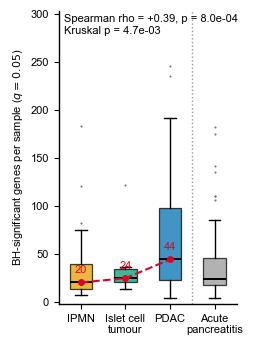

In [55]:
SEV_C = {**STAGE_C, 'Pancreatitis': '#999999'}
SEV_LAB = ['IPMN', 'Islet cell\ntumour', 'PDAC', 'Acute\npancreatitis']
FS = {k: FS_ANNOT_SM for k in ('font.size', 'axes.labelsize', 'xtick.labelsize',
                               'ytick.labelsize', 'legend.fontsize')}
vals = [sev.loc[sev['stage'] == s, 'n_sig'].values for s in SEV_ORDER]
med = [np.median(v) for v in vals[:len(NEOPLASTIC)]]
q1, q3 = np.percentile(sev['n_sig'], [25, 90])

with plt.rc_context(FS):
    fig, ax = plt.subplots(figsize=(2.3, 3.8))
    bp = ax.boxplot(vals, widths=0.5, patch_artist=True,
                    flierprops=dict(marker='o', ms=1.5, mfc='0.45', mec='none'),
                    medianprops=dict(color='black', lw=1.4))
    for box, s in zip(bp['boxes'], SEV_ORDER):
        box.set(facecolor=SEV_C[s], alpha=0.75, lw=0.9)
    ax.plot(range(1, len(NEOPLASTIC) + 1), med, color='#D90429', ls='--', marker='o', lw=1.5, ms=4,
            zorder=5)
    for i, v in enumerate(med):
        ax.annotate(f'{v:.0f}', (i + 1, v), textcoords='offset points', xytext=(0, 7), ha='center',
                    color='#D90429')
    ax.axvline(len(NEOPLASTIC) + 0.5, color='0.6', ls=':', lw=1.0)
    ax.text(0.03, 0.99, f'Spearman rho = {rho:+.2f}, p = {p_rho:.1e}\nKruskal p = {kw:.1e}',
            transform=ax.transAxes, va='top')
    ax.set_xticks(range(1, len(SEV_ORDER) + 1), SEV_LAB)
    ax.set_ylabel('BH-significant genes per sample ($q=0.05$)')
    ax.set_ylim(-2, (q3 + 1.5 * (q3 - q1)) * 1.2)
    fig.savefig(FIG / 'fig_severity_gradient.png', dpi=300, bbox_inches='tight')

In [56]:
gene_set = set(genes)
deg, padj_of = {}, {}
for f in sorted(DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case = f.parent.name.split('__')[1]
    design = f.name.split('.')[0]
    r = pd.read_csv(f, index_col=0)
    deg[(case, design)] = set(r.index[r['padj'].fillna(1.0) < DESEQ2_PADJ]) & gene_set
    padj_of[(case, design)] = r[['padj', 'pvalue', 'log2FoldChange']]

deg_summary = (pd.DataFrame([dict(case=c, design=d, n_sig=len(v)) for (c, d), v in deg.items()])
               .pivot(index='case', columns='design', values='n_sig'))
deg_summary.to_csv(OUT / 'deseq2_nsig_by_case_design.csv')
print(deg_summary.to_string())
print(f'\n{len(deg)} group runs loaded (5 case definitions x 4 designs)')
print('all-run union (reference only, includes Pancreatitis contrasts):',
      len(set().union(*deg.values())))

design              no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
case                                                       
IPMN                           0       97       94      128
IsletCellTumor                 3       60       46       84
PDAC                          83      128      121      164
PancreaticNeoplasm             2       55       77       99
Pancreatitis                   0       38       76       73

20 group runs loaded (5 case definitions x 4 designs)
all-run union (reference only, includes Pancreatitis contrasts): 759


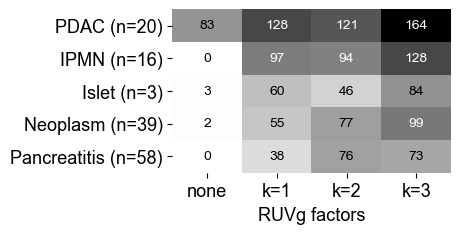

In [57]:
ORDER = ['PDAC', 'IPMN', 'IsletCellTumor', 'PancreaticNeoplasm', 'Pancreatitis']
DESIGN_ORDER = ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
t = deg_summary.loc[ORDER, DESIGN_ORDER]

fig, ax = plt.subplots(figsize=(3.6, 2.12))
ax.imshow(t.values, cmap='Greys', vmin=0, vmax=t.values.max(), aspect='auto')
for i in range(t.shape[0]):
    for j in range(t.shape[1]):
        v = t.values[i, j]
        ax.text(j, i, v, ha='center', va='center',
                color='white' if v > t.values.max() * 0.55 else 'black')
ax.set_xticks(range(4), ['none', 'k=1', 'k=2', 'k=3'])
ax.set_yticks(range(5), [f'{lab} (n={n})' for lab, n in
                         zip(['PDAC', 'IPMN', 'Islet', 'Neoplasm', 'Pancreatitis'],
                             [20, 16, 3, 39, 58])])
ax.set_xlabel('RUVg factors')
for s in ax.spines.values():
    s.set_visible(False)
fig.savefig(FIG / 'fig_group_run_grid.png', dpi=300, bbox_inches='tight')

## Act 1 -- the group list describes nobody

`deg_orphan`: genes at `padj<0.05` in the matched run that are BH-significant in not one patient
that run was built from. `abs_mean_over_sd` / `sign_concordance` ask the same on a continuous
scale over the group's own DE genes.

In [58]:
rng = np.random.default_rng(SEED)
n_hc = SIG_HC.shape[0]


def group_mask(grp):
    return np.ones(len(names_neo), bool) if grp == 'all neoplasm' else (stage_neo == grp)

def hc_union_draws(n, cols=None):
    ns = min(n, n_hc)
    M = SIG_HC if cols is None else SIG_HC[:, cols]
    return ns, np.array([int(M[rng.choice(n_hc, ns, replace=False)].any(axis=0).sum())
                         for _ in range(N_HC_DRAWS)])

rows = []
for design in DESIGN_PAIR:
    for grp, case in CASE_OF.items():
        m = group_mask(grp)
        nmu = set(genes[SIG[m].any(axis=0)])
        D = deg[(case, design)]
        ns, draws = hc_union_draws(int(m.sum()))
        hcu = int(np.median(draws))
        rows.append(dict(design=design, group=grp, n_pat=int(m.sum()), n_hc_drawn=ns,
                         deg_n=len(D), nm_union=len(nmu), hc_union=hcu,
                         nm_over_hc=round(len(nmu) / max(hcu, 1), 2),
                         shared=len(nmu & D), novel=len(nmu - D),
                         deg_orphan=len(D - nmu),
                         deg_orphan_frac=round(len(D - nmu) / max(len(D), 1), 3)))
matched = pd.DataFrame(rows)
matched.to_csv(OUT / 'matched_group_vs_individual.csv', index=False)
print(matched.to_string(index=False))
print('\nn_pat / n_hc_drawn are SAMPLE counts; deg_n / nm_union / hc_union are GENE counts.')
print('the comparison is nm_union vs hc_union at n_pat vs n_hc_drawn samples.')

      design            group  n_pat  n_hc_drawn  deg_n  nm_union  hc_union  nm_over_hc  shared  novel  deg_orphan  deg_orphan_frac
no_covariate             PDAC     20          20     83      1018       118        8.63       6   1012          77            0.928
no_covariate             IPMN     16          16      0       348       109        3.19       0    348           0            0.000
no_covariate Islet Cell Tumor      3           3      3        70         2       35.00       0     70           3            1.000
no_covariate     all neoplasm     39          39      2      1353       254        5.33       1   1352           1            0.500
     ruvg_k2             PDAC     20          20    121      1018       120        8.48      15   1003         106            0.876
     ruvg_k2             IPMN     16          16     94       348       123        2.83       6    342          88            0.936
     ruvg_k2 Islet Cell Tumor      3           3     46        70         2 

In [59]:
carriers = SIG.sum(axis=0)
hc_carriers = SIG_HC.sum(axis=0)
pd.DataFrame(dict(gene=genes, n_patients_sig=carriers, n_hc_sig=hc_carriers)).to_csv(
    OUT / 'gene_carrier_table.csv', index=False)

leg1b = []
for design in DESIGN_PAIR:
    D = sorted(deg[('PancreaticNeoplasm', design)] | deg[('PDAC', design)])
    idx = np.array([gpos[g] for g in D])
    Zu = Z_neo[:, idx]
    mean_z, sd_z = Zu.mean(axis=0), Zu.std(axis=0, ddof=1)
    leg1b.append(pd.DataFrame(dict(design=design, gene=D, mean_z=mean_z, sd_z=sd_z,
                                   abs_mean_over_sd=np.abs(mean_z) / sd_z,
                                   sign_concordance=np.mean(np.sign(Zu) == np.sign(mean_z)[None, :], axis=0),
                                   n_patients_sig=carriers[idx])))
leg1b = pd.concat(leg1b, ignore_index=True)
leg1b.to_csv(OUT / 'mean_representativeness.csv', index=False)

print('representativeness of the group mean over its own DE genes (PDAC + pooled contrast)')
print(leg1b.groupby('design')[['abs_mean_over_sd', 'sign_concordance']]
      .describe(percentiles=[0.5]).round(3).to_string())
for d, sub in leg1b.groupby('design'):
    print(f"  {d}: |mean|/SD < 0.5 in {(sub.abs_mean_over_sd < 0.5).mean():.0%}, "
          f"sign concordance < 0.7 in {(sub.sign_concordance < 0.7).mean():.0%}")

representativeness of the group mean over its own DE genes (PDAC + pooled contrast)
             abs_mean_over_sd                                    sign_concordance                                   
                        count   mean    std    min    50%    max            count   mean    std    min    50%    max
design                                                                                                              
no_covariate             84.0  0.498  0.407  0.003  0.445  2.456             84.0  0.686  0.131  0.385  0.692  1.000
ruvg_k2                 185.0  0.241  0.228  0.001  0.159  1.099            185.0  0.581  0.104  0.410  0.564  0.872
  no_covariate: |mean|/SD < 0.5 in 57%, sign concordance < 0.7 in 55%
  ruvg_k2: |mean|/SD < 0.5 in 86%, sign concordance < 0.7 in 85%


       group  n_pat  nm_union  group_deg_k2  shared_k2  hc_draw_mean  hc_draw_sd
        PDAC     20      1018           121         15         132.6        74.8
        IPMN     16       348            94          6          98.5        69.8
all neoplasm     39      1353            77         21         226.8        54.4


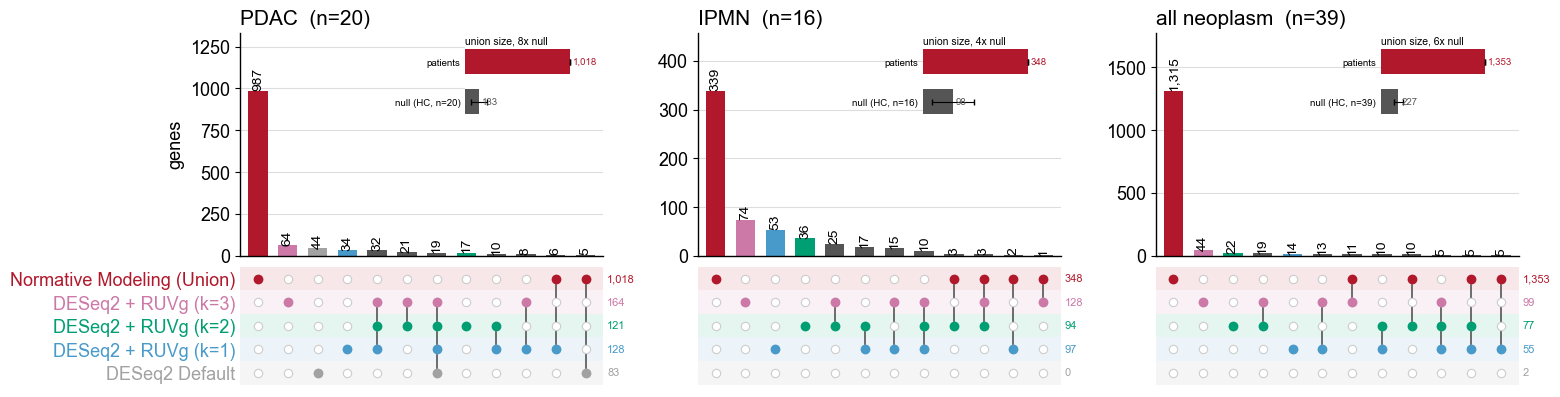

In [60]:
# One summary figure: an UpSet per case definition (three subtypes plus the pooled contrast),
# sets are the four group runs plus the per-patient union. Set labels are shared on the left.
# The healthy-union control is shown once, on the pooled panel, since it answers "is the union
# just noise?" for the whole design rather than per subtype.
UPSET_TOP = 12
VGROUPS = ['PDAC', 'IPMN', 'all neoplasm']  # islet cell tumour is n=3 in the matched arm
UP_DESIGNS = ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
DESIGN_LABEL = {'no_covariate': 'DESeq2 Default', 'ruvg_k1': 'DESeq2 + RUVg (k=1)',
                'ruvg_k2': 'DESeq2 + RUVg (k=2)', 'ruvg_k3': 'DESeq2 + RUVg (k=3)'}
SET_COLOR = {'DESeq2 Default': '#A2A2A2', 'DESeq2 + RUVg (k=1)': '#489ACA',
             'DESeq2 + RUVg (k=2)': '#009E73', 'DESeq2 + RUVg (k=3)': '#CC79A7',
             'Normative Modeling (Union)': '#B2182B'}


def upset(ax_bar, ax_dot, sets, top=UPSET_TOP, ylabels=True):
    names = list(sets)
    cols = [SET_COLOR[n] for n in names]
    memb = {}
    for i, n in enumerate(names):
        for g in sets[n]:
            memb[g] = memb.get(g, 0) | (1 << i)
    combos = [c for c in Counter(memb.values()).most_common() if c[0]][:top]
    x = np.arange(len(combos))

    bar_col = [cols[int(np.log2(m))] if m and not m & (m - 1) else '#555555' for m, _ in combos]
    ax_bar.bar(x, [c[1] for c in combos], color=bar_col, width=0.65)
    for xi, (_, v) in zip(x, combos):
        ax_bar.text(xi, v, f'{v:,}', ha='center', va='bottom', rotation=90)
    ax_bar.set_xlim(-0.6, len(combos) - 0.4)
    ax_bar.set_xticks([])
    ax_bar.set_ylim(0, max(v for _, v in combos) * 1.35)
    ax_bar.set_axisbelow(True)
    ax_bar.grid(axis='y', color='#DDDDDD', lw=0.8)

    for yi in range(len(names)):
        ax_dot.axhspan(yi - 0.5, yi + 0.5, color=cols[yi], alpha=0.10, lw=0)
    for xi, (mask, _) in zip(x, combos):
        on = [i for i in range(len(names)) if mask >> i & 1]
        ax_dot.plot([xi] * len(names), range(len(names)), 'o', ms=6,
                    mfc='white', mec='#CCCCCC', mew=0.8)
        if len(on) > 1:
            ax_dot.plot([xi, xi], [min(on), max(on)], '-', lw=1.2, color='#555555', zorder=1)
        for i in on:
            ax_dot.plot([xi], [i], 'o', ms=6, mfc=cols[i], mec=cols[i], zorder=2)
    for i, n in enumerate(names):
        ax_dot.text(1.01, i, f'{len(sets[n]):,}', transform=ax_dot.get_yaxis_transform(),
                    ha='left', va='center', color=cols[i], fontsize=8)
    ax_dot.set_xlim(-0.6, len(combos) - 0.4)
    ax_dot.set_ylim(-0.6, len(names) - 0.4)
    ax_dot.set_xticks([])
    ax_dot.tick_params(axis='y', length=0)
    if ylabels:
        ax_dot.set_yticks(range(len(names)), names)
        for t, c in zip(ax_dot.get_yticklabels(), cols):
            t.set_color(c)
    else:
        ax_dot.set_yticks([])
    for sp in ax_dot.spines.values():
        sp.set_visible(False)


def null_inset(ax_bar, nmu_n, ns, draws):
    ax = ax_bar.inset_axes([0.62, 0.62, 0.46, 0.32])
    ax.barh([1, 0], [nmu_n, draws.mean()], 0.62, xerr=[0, draws.std()],
            color=['#B2182B', '#555555'], error_kw=dict(lw=0.8, capsize=2))
    for y, v, c in [(1, nmu_n, '#B2182B'), (0, draws.mean(), '#555555')]:
        ax.text(v + nmu_n * 0.03, y, f'{v:,.0f}', va='center', fontsize=7, color=c)
    ax.set_yticks([1, 0], ['patients', f'null (HC, n={ns})'], fontsize=7)
    ax.set_xlim(0, nmu_n * 1.6)
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0)
    ax.set_title(f'union size, {nmu_n / max(draws.mean(), 1):.0f}x null', fontsize=7.5,
                 loc='left', pad=2)
    for sp in ax.spines.values():
        sp.set_visible(False)


def standalone(grp, sets, n_pat, ns, draws):
    f = plt.figure(figsize=(7.5, 4.6))
    g = f.add_gridspec(2, 1, height_ratios=[2.0, 1.1], hspace=0.05)
    ab = f.add_subplot(g[0, 0])
    ad = f.add_subplot(g[1, 0], sharex=ab)
    upset(ab, ad, sets)
    ab.set_ylabel('genes')
    ab.set_title(f'{grp}  (n={n_pat})', loc='left')
    null_inset(ab, len(sets['Normative Modeling (Union)']), ns, draws)
    f.savefig(FIG / f"fig_upset_{grp.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.close(f)


fig = plt.figure(figsize=(5.5 * len(VGROUPS), 4.6))
gs = fig.add_gridspec(2, len(VGROUPS), height_ratios=[2.0, 1.1], hspace=0.05, wspace=0.26)
rows = []
for k, grp in enumerate(VGROUPS):
    m = group_mask(grp)
    sets = {DESIGN_LABEL[d]: deg[(CASE_OF[grp], d)] for d in UP_DESIGNS}
    sets['Normative Modeling (Union)'] = set(genes[SIG[m].any(axis=0)])

    ax_bar = fig.add_subplot(gs[0, k])
    ax_dot = fig.add_subplot(gs[1, k], sharex=ax_bar)
    upset(ax_bar, ax_dot, sets, ylabels=(k == 0))
    ax_bar.set_title(f'{grp}  (n={int(m.sum())})', loc='left')
    if k == 0:
        ax_bar.set_ylabel('genes')

    nmu = sets['Normative Modeling (Union)']
    ns, draws = hc_union_draws(int(m.sum()))
    rows.append(dict(group=grp, n_pat=int(m.sum()), nm_union=len(nmu),
                     group_deg_k2=len(deg[(CASE_OF[grp], RUVG_PICK)]),
                     shared_k2=len(deg[(CASE_OF[grp], RUVG_PICK)] & nmu),
                     hc_draw_mean=round(draws.mean(), 1), hc_draw_sd=round(draws.std(), 1)))

    # the "is the union just noise?" control, in the empty corner of every panel
    null_inset(ax_bar, len(nmu), ns, draws)

    # per-group version of the same figure, saved to disk only
    standalone(grp, sets, int(m.sum()), ns, draws)

fig.savefig(FIG / 'fig_upset_summary.png', dpi=300, bbox_inches='tight')
summary = pd.DataFrame(rows)
summary.to_csv(OUT / 'upset_group_vs_individual.csv', index=False)
print(summary.to_string(index=False))

In [61]:
def pair_jaccard(M, max_pairs=4000, seed=SEED):
    r = np.random.default_rng(seed)
    n = M.shape[0]
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    if len(pairs) > max_pairs:
        pairs = [pairs[k] for k in r.choice(len(pairs), max_pairs, replace=False)]
    out = []
    for i, j in pairs:
        u = int((M[i] | M[j]).sum())
        if u:
            out.append(int((M[i] & M[j]).sum()) / u)
    return np.array(out)


def size_matched_null(M, seed=SEED):
    r = np.random.default_rng(seed)
    N = M.shape[1]
    Mn = np.zeros_like(M)
    for i, k in enumerate(M.sum(axis=1)):
        if k:
            Mn[i, r.choice(N, int(k), replace=False)] = True
    return Mn


j_pat = pair_jaccard(SIG)
j_hc = pair_jaccard(SIG_HC)
j_null = pair_jaccard(size_matched_null(SIG))
spec = pd.DataFrame([dict(set_='patients', n_pairs=len(j_pat), median=np.median(j_pat), mean=j_pat.mean()),
                     dict(set_='HC (batch-matched)', n_pairs=len(j_hc), median=np.median(j_hc), mean=j_hc.mean()),
                     dict(set_='size-matched null', n_pairs=len(j_null), median=np.median(j_null), mean=j_null.mean())])
spec.to_csv(OUT / 'patient_specificity_jaccard.csv', index=False)
print(spec.round(4).to_string(index=False))

share = pd.Series(carriers[carriers > 0]).value_counts().sort_index()
carrier_dist = share.rename('n_genes').rename_axis('n_patients_sharing').reset_index()
carrier_dist.to_csv(OUT / 'gene_carrier_distribution.csv', index=False)
print('\nhow many patients share a gene (the group-list premise is that this mass sits high)')
print(carrier_dist.head(10).to_string(index=False))
print(f"genes carried by exactly 1 patient: {int(share.get(1, 0))} of {int((carriers > 0).sum())} "
      f"({share.get(1, 0) / max((carriers > 0).sum(), 1):.0%})")

              set_  n_pairs  median   mean
          patients      741     0.0 0.0036
HC (batch-matched)      750     0.0 0.0001
 size-matched null      741     0.0 0.0005

how many patients share a gene (the group-list premise is that this mass sits high)
 n_patients_sharing  n_genes
                  1     1197
                  2      131
                  3       22
                  4        2
                  5        1
genes carried by exactly 1 patient: 1197 of 1353 (88%)


## Act 3 -- what the group contrast never sees: pancreas cell-type markers

The panel is derived from PanglaoDB, not hand-listed. Its cell-type sets are not tissue-exclusive
and plasma cfRNA is dominated by blood cell types, so each gene is counted across every
non-pancreatic set in the library and kept only if it appears in at most `MAX_OTHER_SETS` of them;
genes landing in more than one of the three pancreas groups are dropped as ambiguous.

In [62]:
PANGLAO_LIB = 'PanglaoDB_Augmented_2021'
PANGLAO_GROUPS = {'acinar': ['Acinar Cells'],
                  'islet': ['Alpha Cells', 'Beta Cells', 'Delta Cells', 'Gamma (PP) Cells'],
                  'ductal': ['Ductal Cells']}
PANGLAO_PANCREAS_OTHER = ['Pancreatic Progenitor Cells', 'Pancreatic Stellate Cells',
                          'Peri-islet Schwann Cells', 'Neuroendocrine Cells',
                          'Enteroendocrine Cells']
MAX_OTHER_SETS = 1
MARKER_Z = 1.96

lib_path = config.GROUP_VS_INDIV_DIR / f'{PANGLAO_LIB}.pkl'
if lib_path.exists():
    lib = pickle.load(open(lib_path, 'rb'))
else:
    lib = gp.get_library(PANGLAO_LIB, organism='human')
    pickle.dump(lib, open(lib_path, 'wb'))

panc_terms = set(sum(PANGLAO_GROUPS.values(), [])) | set(PANGLAO_PANCREAS_OTHER)
other_sets = Counter()
for t, gl in lib.items():
    if t not in panc_terms:
        other_sets.update(set(gl))

grp_of = {}
for lab, terms in PANGLAO_GROUPS.items():
    for sym in set().union(*[set(lib[t]) for t in terms]):
        if other_sets[sym] <= MAX_OTHER_SETS:
            grp_of.setdefault(sym, set()).add(lab)
ambiguous = sorted(s for s, g in grp_of.items() if len(g) > 1)
MARKER_SETS = {lab: sorted(s for s, g in grp_of.items() if g == {lab}) for lab in PANGLAO_GROUPS}

print(f'{PANGLAO_LIB}: {len(lib)} cell types, {len(panc_terms)} treated as pancreatic')
print(f'kept if present in <= {MAX_OTHER_SETS} non-pancreatic sets')
print(pd.DataFrame([dict(set=lab, panglao_raw=len(set().union(*[set(lib[t]) for t in terms])),
                         specific=len(MARKER_SETS[lab]))
                    for lab, terms in PANGLAO_GROUPS.items()]).to_string(index=False))
print(f'dropped as ambiguous within the panel ({len(ambiguous)}): {ambiguous}')

with h5py.File(config.H5AD_PATH, 'r') as h:
    var_index = dec(h['var/_index'][()])
    g = h['var/GeneName']
    var_sym = pd.Categorical.from_codes(g['codes'][()], dec(g['categories'][()])).astype(str)
sym_to_ens = pd.Series(var_index, index=var_sym)
sym_of = pd.Series(var_sym, index=var_index)

ens_of = {}
for s, gl in MARKER_SETS.items():
    for sym in gl:
        for e in np.atleast_1d(sym_to_ens.get(sym, [])):
            if e in gpos:
                ens_of[e] = (s, sym)
marker_tbl = pd.DataFrame([dict(ens=e, set=s, symbol=sym) for e, (s, sym) in ens_of.items()])
print(f'\nengine-modeled ENSG ids on the panel: {len(marker_tbl)} of '
      f'{sum(len(v) for v in MARKER_SETS.values())} symbols')
print(marker_tbl.groupby('set').size().to_string())

PanglaoDB_Augmented_2021: 178 cell types, 11 treated as pancreatic
kept if present in <= 1 non-pancreatic sets
   set  panglao_raw  specific
acinar          124        28
 islet          318        79
ductal          132         5
dropped as ambiguous within the panel (8): ['AKR1C3', 'GCG', 'GDF15', 'INS', 'KCNK16', 'PDX1', 'UBD', 'UCN3']

engine-modeled ENSG ids on the panel: 106 of 112 symbols
set
acinar    24
ductal     5
islet     77


In [63]:
def raw_counts(samples, ens_list):
    with h5py.File(config.H5AD_PATH, 'r') as h:
        obs_index = list(dec(h['obs/_index'][()]))
        vpos = {e: i for i, e in enumerate(dec(h['var/_index'][()]))}
        cols = np.array([vpos[e] for e in ens_list])
        indptr = h['X/indptr'][()]
        out = np.zeros((len(samples), len(cols)))
        lib = np.zeros(len(samples))
        for r, s in enumerate(samples):
            i = obs_index.index(s)
            sl = slice(indptr[i], indptr[i + 1])
            idx, dat = h['X/indices'][sl], h['X/data'][sl]
            lib[r] = dat.sum()
            pos = pd.Series(np.arange(len(idx)), index=idx).reindex(cols).values
            ok = ~pd.isna(pos)
            out[r, ok] = dat[pos[ok].astype(int)]
    return out, lib


ens_list = marker_tbl['ens'].tolist()
cnt, lib = raw_counts(np.concatenate([names_neo, names_hc]), ens_list)
is_pat = np.arange(len(cnt)) < len(names_neo)
cpm = cnt / lib[:, None] * 1e6

rows = []
for s in MARKER_SETS:
    c = marker_tbl['set'].values == s
    tot = cnt[:, c].sum(axis=1)
    cs = cpm[:, c].sum(axis=1)
    a, b = int((tot[is_pat] > 0).sum()), int((tot[~is_pat] > 0).sum())
    rows.append(dict(set=s, n_ens=int(c.sum()),
                     pat_detected=f'{a}/{is_pat.sum()}', hc_detected=f'{b}/{(~is_pat).sum()}',
                     pat_reads=int(tot[is_pat].sum()), hc_reads=int(tot[~is_pat].sum()),
                     pat_cpm=cs[is_pat].mean(), hc_cpm=cs[~is_pat].mean()))
detect = pd.DataFrame(rows)
detect.to_csv(OUT / 'marker_raw_detectability.csv', index=False)
print('is the transcript measurable at all? (raw counts, same samples)')
print(detect.round(4).to_string(index=False))

per_gene = pd.DataFrame(dict(
    set=marker_tbl['set'], symbol=marker_tbl['symbol'],
    pat_nz=(cnt[is_pat] > 0).sum(axis=0), hc_nz=(cnt[~is_pat] > 0).sum(axis=0),
    pat_reads=cnt[is_pat].sum(axis=0).astype(int), hc_reads=cnt[~is_pat].sum(axis=0).astype(int)))
per_gene.to_csv(OUT / 'marker_raw_per_gene.csv', index=False)
print('\nzero everywhere:', sorted(per_gene.loc[(per_gene.pat_reads == 0) & (per_gene.hc_reads == 0), 'symbol']))
print('top contributors:', per_gene.nlargest(4, 'pat_reads')[['symbol', 'pat_reads', 'hc_reads']].to_dict('records'))

is the transcript measurable at all? (raw counts, same samples)
   set  n_ens pat_detected hc_detected  pat_reads  hc_reads  pat_cpm   hc_cpm
acinar     24        34/39       42/48       7472      9995   9.6088  10.5604
 islet     77        39/39       48/48     320833    466482 451.9842 470.3131
ductal      5        29/39       41/48       3714      5778   4.7224   6.7413

zero everywhere: ['AQP12A', 'CELA2A', 'CELA3A', 'CELA3B', 'CLPS', 'CPA2', 'GPR148', 'PAX4', 'PNLIP', 'POU3F4', 'PRSS2', 'PTF1A', 'SYCN']
top contributors: [{'symbol': 'FXYD5', 'pat_reads': 120899, 'hc_reads': 184859}, {'symbol': 'MEIS1', 'pat_reads': 40995, 'hc_reads': 46332}, {'symbol': 'STXBP5', 'pat_reads': 27404, 'hc_reads': 37259}, {'symbol': 'PXK', 'pat_reads': 23941, 'hc_reads': 42426}]


In [64]:
MARKER_MIN_DETECT = 0.10

nz_frac = (cnt > 0).mean(axis=0)
marker_tbl['detect_frac'] = nz_frac
marker_tbl['detected'] = nz_frac >= MARKER_MIN_DETECT
marker_tbl.to_csv(OUT / 'marker_panel.csv', index=False)

mcols = np.array([gpos[e] for e in marker_tbl['ens']])
Zm_pat, Zm_hc = Z_neo[:, mcols], Z_hc_qc[:, mcols]            # matched arm (b1), DESeq2-paired
Zm_A, Zm_hc_A = Z_A[:, mcols], Z_hc_A[:, mcols]               # all arm (b1-b3), hit-level panels
zero_col = nz_frac == 0
print('randomized-quantile Z is not defined by data on a gene with no reads:')
print(f'  marker ENSG with zero counts in all {len(cnt)} samples: {int(zero_col.sum())}/{len(nz_frac)} '
      f'({sorted(marker_tbl.loc[zero_col, "symbol"])})')
print(f'  |Z|>{MARKER_Z} rate there: patient {(np.abs(Zm_pat[:, zero_col]) > MARKER_Z).mean():.3f}, '
      f'HC {(np.abs(Zm_hc[:, zero_col]) > MARKER_Z).mean():.3f}  (0.05 = pure noise)')
print(f'  on detected markers: patient {(np.abs(Zm_pat[:, marker_tbl["detected"]]) > MARKER_Z).mean():.3f}, '
      f'HC {(np.abs(Zm_hc[:, marker_tbl["detected"]]) > MARKER_Z).mean():.3f}')
print(f'\nany-hit rate on the full panel is a set-size counter, not a signal '
      f'(HC should sit at 1-0.95^n if every column were noise):')
for s in MARKER_SETS:
    c = marker_tbl['set'].values == s
    print(f'  {s:7s} n={int(c.sum()):2d}  noise expectation {1 - 0.95 ** c.sum():.2f}  '
          f'HC observed {(np.abs(Zm_hc[:, c]) > MARKER_Z).any(axis=1).mean():.2f}  '
          f'patient {(np.abs(Zm_pat[:, c]) > MARKER_Z).any(axis=1).mean():.2f}')
print(f'\nmarkers surviving detect_frac >= {MARKER_MIN_DETECT}: '
      f'{int(marker_tbl["detected"].sum())}/{len(marker_tbl)}')
print(marker_tbl[marker_tbl['detected']][['set', 'symbol', 'detect_frac']]
      .sort_values(['set', 'detect_frac'], ascending=[True, False]).round(3).to_string(index=False))

randomized-quantile Z is not defined by data on a gene with no reads:
  marker ENSG with zero counts in all 87 samples: 13/106 (['AQP12A', 'CELA2A', 'CELA3A', 'CELA3B', 'CLPS', 'CPA2', 'GPR148', 'PAX4', 'PNLIP', 'POU3F4', 'PRSS2', 'PTF1A', 'SYCN'])
  |Z|>1.96 rate there: patient 0.049, HC 0.037  (0.05 = pure noise)
  on detected markers: patient 0.087, HC 0.077

any-hit rate on the full panel is a set-size counter, not a signal (HC should sit at 1-0.95^n if every column were noise):
  acinar  n=24  noise expectation 0.71  HC observed 0.71  patient 0.77
  islet   n=77  noise expectation 0.98  HC observed 1.00  patient 1.00
  ductal  n= 5  noise expectation 0.23  HC observed 0.25  patient 0.36

markers surviving detect_frac >= 0.1: 53/106
   set  symbol  detect_frac
acinar   AMY2B        0.839
acinar     CEL        0.115
acinar   CTRB2        0.103
ductal  ATP8B1        0.747
ductal ONECUT1        0.207
ductal   DCDC2        0.126
ductal    SAA1        0.115
 islet   FXYD5        1.000
 

In [65]:
grp_rows = []
for f in sorted(DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case, design = f.parent.name.split('__')[1], f.name.split('.')[0]
    if case not in ('PDAC', 'PancreaticNeoplasm'):
        continue
    r = pd.read_csv(f, index_col=0)
    for s in MARKER_SETS:
        ens = [e for e in marker_tbl.loc[marker_tbl['set'] == s, 'ens'] if e in r.index]
        sub = r.loc[ens]
        grp_rows.append(dict(case=case, design=design, set=s,
                             n_in_table=len(sub), n_tested=int(sub.padj.notna().sum()),
                             n_padj05=int((sub.padj < 0.05).sum()),
                             n_rawp05=int((sub.pvalue < 0.05).sum()),
                             min_padj=sub.padj.min(), med_lfc=sub.log2FoldChange.median(),
                             all_sig_transcriptome=int((r.padj < 0.05).sum())))
group_side = pd.DataFrame(grp_rows)
group_side.to_csv(OUT / 'marker_group_deseq2.csv', index=False)
print('what the group contrast sees on the same markers')
print(group_side.round(3).to_string(index=False))

nominal = []
for f in sorted(DEG_DIR.glob('moore_b1__*/*.csv.gz')):
    case, design = f.parent.name.split('__')[1], f.name.split('.')[0]
    if case not in ('PDAC', 'PancreaticNeoplasm'):
        continue
    r = pd.read_csv(f, index_col=0)
    ens = [e for e in marker_tbl['ens'] if e in r.index]
    sub = r.loc[ens]
    for e, row in sub[sub.pvalue < 0.05].iterrows():
        nominal.append(dict(case=case, design=design, symbol=ens_of[e][1], set=ens_of[e][0],
                            lfc=row.log2FoldChange, pvalue=row.pvalue, padj=row.padj))
print('\nmarkers reaching raw p<0.05 in any group design (none reach padj<0.05):')
print(pd.DataFrame(nominal).round(4).to_string(index=False) if nominal else '  none')

what the group contrast sees on the same markers
              case       design    set  n_in_table  n_tested  n_padj05  n_rawp05  min_padj  med_lfc  all_sig_transcriptome
              PDAC no_covariate acinar          12         0         0         0       NaN    0.180                     83
              PDAC no_covariate  islet          68         1         0         3     0.600    0.030                     83
              PDAC no_covariate ductal           5         0         0         0       NaN    3.121                     83
              PDAC      ruvg_k1 acinar          12        12         0         1     0.565   -0.320                    130
              PDAC      ruvg_k1  islet          68        68         1         5     0.000    0.052                    130
              PDAC      ruvg_k1 ductal           5         5         1         2     0.031    3.242                    130
              PDAC      ruvg_k2 acinar          12        12         0         0     0.758

In [66]:
DET = marker_tbl['detected'].values
# hit level, not a cutoff sweep: no group contrast is on the other side, so this runs on the
# all arm (Moore Batch_1-3) rather than the DESeq2-matched subset
hit_pat, hit_hc = np.abs(Zm_A) > MARKER_Z, np.abs(Zm_hc_A) > MARKER_Z


def set_count(c, thr):
    a = int((hit_pat[:, c].sum(axis=1) >= thr).sum())
    b = int((hit_hc[:, c].sum(axis=1) >= thr).sum())
    return dict(n_genes=int(c.sum()), min_hits=thr, pat=f'{a}/{len(hit_pat)}', hc=f'{b}/{len(hit_hc)}',
                pat_frac=a / len(hit_pat), hc_frac=b / len(hit_hc))


rows = []
for s in list(MARKER_SETS) + ['all']:
    base = np.ones(len(DET), bool) if s == 'all' else (marker_tbl['set'].values == s)
    for panel, flag in (('full', base), ('detected', base & DET)):
        if flag.sum() == 0:
            continue
        for thr in (1, 2):
            rows.append(dict(set=s, panel=panel, **set_count(flag, thr)))
indiv = pd.DataFrame(rows)
indiv['headline'] = (indiv.panel == 'detected') & (indiv.min_hits == 1) & (indiv['set'] != 'all')
indiv.to_csv(OUT / 'marker_individual_hits.csv', index=False)
print(f'per-sample deviation on the markers (|Z|>{MARKER_Z}), counts only -- no patient-group vs')
print('HC-group test is computed here: pooling samples into two groups and testing the means is the')
print('operation this notebook is arguing against. The HC column is the reference to read by eye.')
print(indiv.round(4).to_string(index=False))

prof = pd.DataFrame(dict(sample=names_A, stage=stage_A, n_hit=hit_pat[:, DET].sum(axis=1)))
for s in MARKER_SETS:
    prof[f'n_{s}'] = hit_pat[:, (marker_tbl['set'].values == s) & DET].sum(axis=1)
sym_det = marker_tbl['symbol'].values
prof['markers'] = [' '.join(f'{sym_det[j]}{Zm_A[i, j]:+.1f}'
                            for j in np.where(hit_pat[i] & DET)[0]) for i in range(len(prof))]
prof['markers_undetected'] = [' '.join(f'{sym_det[j]}{Zm_A[i, j]:+.1f}'
                                       for j in np.where(hit_pat[i] & ~DET)[0]) for i in range(len(prof))]
prof = prof.sort_values('n_hit', ascending=False)
prof.to_csv(OUT / 'marker_per_patient_profile.csv', index=False)
print('\nper-patient profiles on detected markers only (top 10); the last column is what the '
      'zero/low-count columns would have added as noise')
print(prof.head(10)[['sample', 'stage', 'n_hit', 'markers']].to_string(index=False))
print('\nby stage, frac with >=1 hit on detected markers:')
print(pd.DataFrame({'stage': stage_A, 'h': hit_pat[:, DET].sum(axis=1) > 0})
      .groupby('stage', observed=True)['h'].agg(n='size', frac='mean').round(2).to_string())

per-sample deviation on the markers (|Z|>1.96), counts only -- no patient-group vs
HC-group test is computed here: pooling samples into two groups and testing the means is the
operation this notebook is arguing against. The HC column is the reference to read by eye.
   set    panel  n_genes  min_hits   pat    hc  pat_frac  hc_frac  headline
acinar     full       24         1 58/72 51/70    0.8056   0.7286     False
acinar     full       24         2 32/72 23/70    0.4444   0.3286     False
acinar detected        3         1 15/72 19/70    0.2083   0.2714      True
acinar detected        3         2  1/72  1/70    0.0139   0.0143     False
 islet     full       77         1 72/72 70/70    1.0000   1.0000     False
 islet     full       77         2 72/72 69/70    1.0000   0.9857     False
 islet detected       46         1 70/72 68/70    0.9722   0.9714      True
 islet detected       46         2 65/72 66/70    0.9028   0.9429     False
ductal     full        5         1 30/72 19/70   

In [67]:
# Act 3 headline: on the same marker panel, how many genes does each view recover? Group side =
# DESeq2 padj<0.05. Individual side = per-sample BH q<0.05 in >=1 patient (act 2's union restricted
# to the panel). Control = that union on batch-matched HC at the same n, median and max over draws.
PANELS = {'full': np.ones(len(marker_tbl), bool), 'detected': marker_tbl['detected'].values}

rows = []
for pname, pmask in PANELS.items():
    pens = marker_tbl['ens'].values[pmask]
    pcols = np.array([gpos[e] for e in pens])
    pset = set(pens)
    for design in DESIGN_PAIR:
        for grp, case in CASE_OF.items():
            m = group_mask(grp)
            nm_m = set(pens[SIG[m][:, pcols].any(axis=0)])
            ns, draws = hc_union_draws(int(m.sum()), cols=pcols)
            rows.append(dict(panel=pname, n_panel=int(pmask.sum()), design=design, group=grp,
                             n_pat=int(m.sum()), n_hc_drawn=ns,
                             group_deg=len(pset & deg[(case, design)]), nm_union=len(nm_m),
                             hc_union_med=float(np.median(draws)), hc_union_max=int(draws.max()),
                             nm_minus_hcmax=len(nm_m) - int(draws.max())))
recovery = pd.DataFrame(rows)
recovery.to_csv(OUT / 'marker_recovery_group_vs_union.csv', index=False)
print('marker GENES recovered by each view. n_pat / n_hc_drawn are SAMPLE counts -- they say the')
print('HC baseline was built at the same size, not how many genes it found. Read group_deg vs')
print('nm_union vs hc_union_med, all three of them gene counts on the same panel.')
print(recovery.to_string(index=False))

any_group = set().union(*deg.values())
for pname, pmask in PANELS.items():
    pens = set(marker_tbl['ens'].values[pmask])
    print(f'{pname} panel (n={len(pens)}): markers at padj<0.05 in ANY of the {len(deg)} '
          f'group runs = {len(pens & any_group)}')

marker GENES recovered by each view. n_pat / n_hc_drawn are SAMPLE counts -- they say the
HC baseline was built at the same size, not how many genes it found. Read group_deg vs
nm_union vs hc_union_med, all three of them gene counts on the same panel.
   panel  n_panel       design            group  n_pat  n_hc_drawn  group_deg  nm_union  hc_union_med  hc_union_max  nm_minus_hcmax
    full      106 no_covariate             PDAC     20          20          0         8           0.0             0               8
    full      106 no_covariate             IPMN     16          16          0         3           0.0             0               3
    full      106 no_covariate Islet Cell Tumor      3           3          0         1           0.0             0               1
    full      106 no_covariate     all neoplasm     39          39          0        11           0.0             0              11
    full      106      ruvg_k2             PDAC     20          20          1         8 

In [68]:
# The named genes behind those counts, with the best result the group side achieves anywhere
# across all 20 runs placed next to the per-sample result.
allres = pd.concat(padj_of.values())
best_padj = allres.groupby(level=0)['padj'].min()
best_rawp = allres.groupby(level=0)['pvalue'].min()
best_lfc = allres.groupby(level=0)['log2FoldChange'].median()

ledger = marker_tbl.copy()
ledger['n_pat_bh'] = SIG[:, mcols].sum(axis=0)
ledger['n_hc_bh'] = SIG_HC[:, mcols].sum(axis=0)
ledger['n_pat_z196'] = (np.abs(Zm_pat) > MARKER_Z).sum(axis=0)
ledger['n_hc_z196'] = (np.abs(Zm_hc) > MARKER_Z).sum(axis=0)
ledger['group_best_padj'] = ledger['ens'].map(best_padj)
ledger['group_best_rawp'] = ledger['ens'].map(best_rawp)
ledger['group_med_lfc'] = ledger['ens'].map(best_lfc)
ledger['group_sig_any'] = ledger['group_best_padj'].fillna(1.0) < DESEQ2_PADJ
ledger = ledger.sort_values(['n_pat_bh', 'n_pat_z196'], ascending=False)
ledger.to_csv(OUT / 'marker_ledger.csv', index=False)

cols = ['set', 'symbol', 'detect_frac', 'n_pat_bh', 'n_hc_bh', 'n_pat_z196', 'n_hc_z196',
        'group_best_padj', 'group_best_rawp', 'group_sig_any']
print('per-marker: individual side vs the best the group side manages in any of 20 runs')
print(ledger.loc[ledger['detected'] | (ledger['n_pat_bh'] > 0), cols].round(4).to_string(index=False))
nsig = ledger['n_pat_bh'] > 0
print(f'\nmarkers BH-significant in >=1 patient: {int(nsig.sum())}, of which '
      f'{int((nsig & ~ledger["group_sig_any"]).sum())} are padj>=0.05 in every group run')
print(f'same restricted to the detected panel: {int((nsig & ledger["detected"]).sum())}')

per-marker: individual side vs the best the group side manages in any of 20 runs
   set   symbol  detect_frac  n_pat_bh  n_hc_bh  n_pat_z196  n_hc_z196  group_best_padj  group_best_rawp  group_sig_any
 islet    UNC5C       0.3563         2        0           9          4           0.5618           0.0077          False
 islet    FXYD5       1.0000         1        0          13         10           0.5998           0.1728          False
acinar    CTRB2       0.1034         1        0           6          5           0.9950           0.0646          False
ductal     SAA1       0.1149         1        0           6          2           0.0000           0.0000           True
acinar     CPB1       0.0805         1        0           5          3           0.5655           0.0121          False
 islet    LOXL4       0.0575         1        0           4          2           0.8403           0.1639          False
 islet  RIPPLY2       0.0460         1        0           3          4         

q<0.01: 8 sample-level hits, 8 with a nonzero raw count in that sample
q<0.05: 12 sample-level hits, 12 with a nonzero raw count in that sample
q<0.1: 16 sample-level hits, 14 with a nonzero raw count in that sample
q<0.2: 29 sample-level hits, 25 with a nonzero raw count in that sample
q<0.3: 38 sample-level hits, 30 with a nonzero raw count in that sample
grid: 30 markers x 42 patients; q<0.05 tiles drawn 26 of 28
 cutoff  markers  patients  hc_markers  no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
   0.01        7         7           0             0        1        0        1
   0.05       11         8           0             0        1        0        1
   0.10       14        12           0             0        1        0        1
   0.20       23        22           4             0        1        0        2
   0.30       27        25          14             0        1        2        3


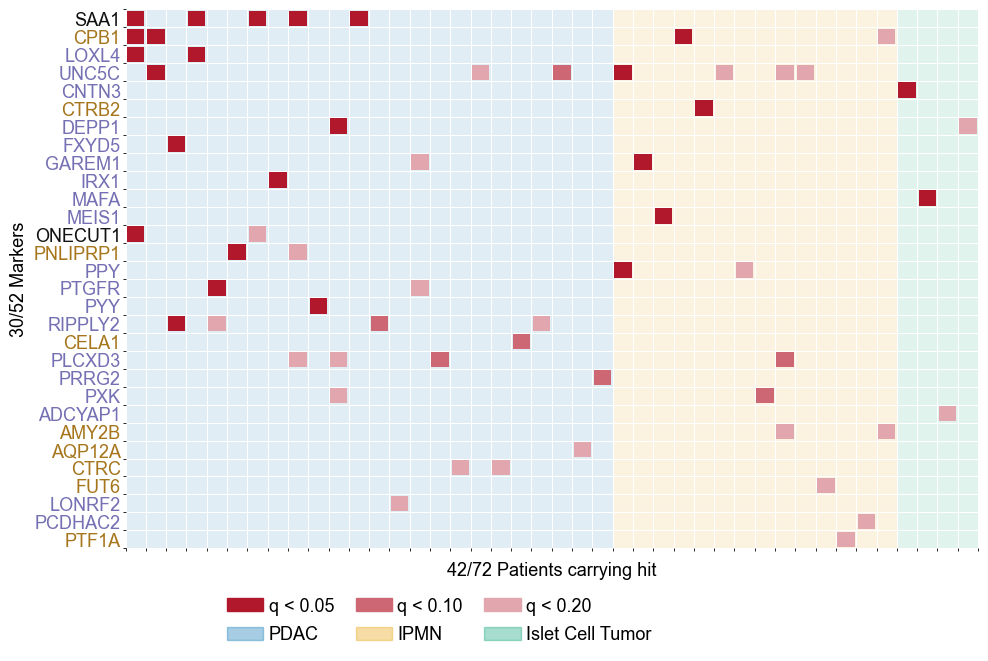

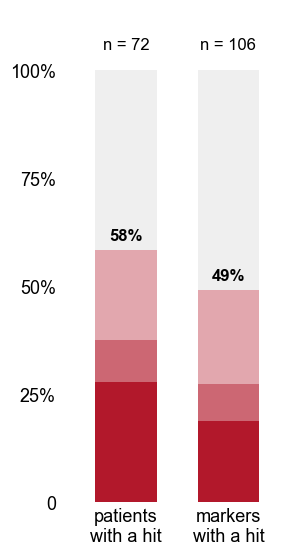

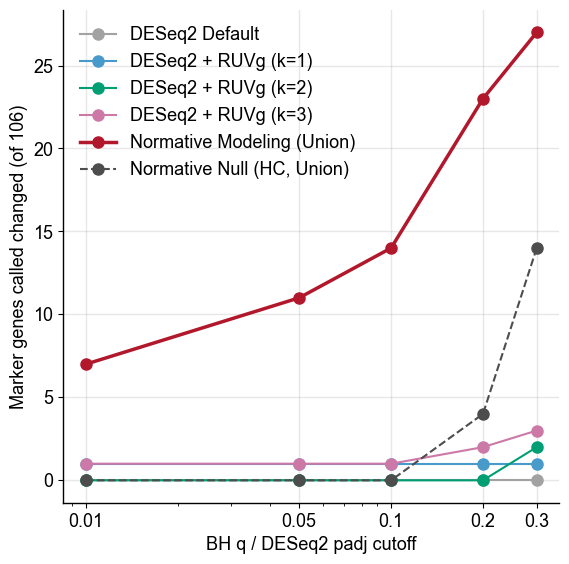

In [69]:
SET_C = {'acinar': '#A6761D', 'islet': '#7570B3', 'ductal': '#111111'}
Q_TIERS = [0.05, 0.10, 0.20]
Q_GRID = [0.01, 0.05, 0.10, 0.20, 0.30]
TOP_ROWS = 30  # row cap: more markers get a hit than fit as readable labels
BAR_W, BAR_GAP = 0.9, 1.5 
LABELS = {
    'grid_x': '{n_pat_hit}/{n_pat} Patients carrying hit',
    'grid_y': '{n_rows}/{n_markers_hit} Markers',
    'bar_x': ('patients\nwith a hit', 'markers\nwith a hit'),
    'bar_n': 'n = {n}',
    'sweep_x': 'BH q / DESeq2 padj cutoff',
    'sweep_y': '{ylab} (of {n_panel})',
}


def marker_recovery_fig(mtbl, fname, ylab, color='#B2182B', row_colors=None,
                        detected_only=False, nz=None, labels=None):
    lab_of = {**LABELS, **(labels or {})}
    cols = np.array([gpos[e] for e in mtbl['ens']])
    # the grid and the bars show hit level, so they run on the all arm (Moore Batch_1-3); the
    # sweep puts DESeq2 padj next to BH q on the same axis, so it stays on the DESeq2-matched b1
    sig_A = {q: bh_sig_matrix(Z_A, q=q)[:, cols] for q in Q_TIERS}
    sig_q = {q: bh_sig_matrix(Z_neo, q=q)[:, cols] for q in Q_GRID}
    sig_hc_q = {q: bh_sig_matrix(Z_hc_qc, q=q)[:, cols] for q in Q_GRID}
    use = mtbl['detected'].values if detected_only else np.ones(len(mtbl), bool)
    tier = np.zeros(sig_A[Q_TIERS[0]].shape)
    for i, q in enumerate(sorted(Q_TIERS, reverse=True)):
        tier[sig_A[q]] = i + 1
    tier[:, ~use] = 0

    # three separate figures, saved as <stem>_grid / _bars / _sweep
    stem = Path(fname).stem
    fig_grid, ax = plt.subplots(figsize=(11.0, 7.0))
    hit = tier > 0
    cand = list(np.where(hit.any(axis=0))[0])
    rows, shown = [], np.zeros(tier.shape[0], bool)
    while cand and len(rows) < TOP_ROWS:
        gain = [(int((hit[:, c] & ~shown).sum()), int(tier[:, c].max()), int(hit[:, c].sum()))
                for c in cand]
        if max(g[0] for g in gain) == 0:
            shown[:] = False
            continue
        best = cand[max(range(len(cand)), key=lambda i: gain[i])]
        rows.append(best)
        shown |= hit[:, best]
        cand.remove(best)
    rows = np.array(rows)
    rows = rows[np.lexsort((mtbl['symbol'].values[rows], -tier[:, rows].max(axis=0),
                            -(tier[:, rows] == len(Q_TIERS)).sum(axis=0)))]
    keep = np.where(tier.max(axis=1) > 0)[0]
    keep = keep[np.lexsort((-(tier[np.ix_(keep, rows)] == len(Q_TIERS)).sum(axis=1),
                            [list(STAGE_C).index(s) for s in stage_A[keep]]))]
    T = tier[np.ix_(keep, rows)].T
    ax.imshow(np.zeros(T.shape), cmap='Greys', vmin=0, vmax=1, aspect='auto')
    shades = [mcolors.to_hex(1 - w + w * np.array(mcolors.to_rgb(color))) for w in (1.0, 0.66, 0.38)]
    tier_h = []
    for lvl, sh in zip(range(len(Q_TIERS), 0, -1), shades):
        for y, x in zip(*np.where(T == lvl)):
            ax.add_patch(plt.Rectangle((x - 0.43, y - 0.43), 0.86, 0.86, color=sh, lw=0, zorder=2))
        tier_h.append(plt.Rectangle((0, 0), 1, 1, color=sh))
    # a patch in data coords, not axvspan: axvspan spans the whole axes and spills past the
    # first and last gridline by half a line width
    for j, sm in enumerate(stage_A[keep]):
        ax.add_patch(plt.Rectangle((j - 0.5, -0.5), 1, len(rows), color=STAGE_C[sm],
                                   alpha=0.12, lw=0, zorder=0))
    ax.set_xlim(-0.5, len(keep) - 0.5)
    ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, len(keep), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(rows), 1), minor=True)
    ax.grid(which='minor', color='#FFFFFF', lw=0.8)
    ax.set_yticks(range(len(rows)), [mtbl['symbol'].values[r] for r in rows])
    if row_colors is not None:
        for t, r in zip(ax.get_yticklabels(), rows):
            t.set_color(row_colors[r])
    ax.set_xticks([])
    ax.set_xlabel(lab_of['grid_x'].format(n_pat_hit=len(keep), n_pat=tier.shape[0]))
    ax.set_ylabel(lab_of['grid_y'].format(n_rows=len(rows),
                                          n_markers_hit=int((tier.max(axis=0) > 0).sum())))
    ax.tick_params(length=0)
    h2 = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in STAGE_C.values()]
    l1 = [f'q < {q:.2f}' for q in sorted(Q_TIERS)]
    hh = [x for pair in zip(tier_h, h2) for x in pair]
    ll = [x for pair in zip(l1, STAGE_C) for x in pair]
    ax.legend(hh, ll, frameon=False, loc='upper left', bbox_to_anchor=(0.1, -0.06), ncol=3,
              handletextpad=0.3, columnspacing=1.2, labelspacing=0.6)
    for sp in ax.spines.values():
        sp.set_visible(False)

    # middle: the two grid margins as fractions, stacked by the q that earned them
    fig_grid.savefig(FIG / f'{stem}_grid.png', dpi=300, bbox_inches='tight')

    fig_bar, ax = plt.subplots(figsize=(3, 6.4))
    pat_f = [(sig_A[q][:, use].sum(axis=1) > 0).mean() for q in sorted(Q_TIERS)]
    mrk_f = [(sig_A[q][:, use].sum(axis=0) > 0).mean() for q in sorted(Q_TIERS)]
    xs = [0, BAR_GAP]
    for x, (fr, n) in zip(xs, zip([pat_f, mrk_f], [tier.shape[0], int(use.sum())])):
        bot = 0
        for seg, sh in zip([fr[0], fr[1] - fr[0], fr[2] - fr[1]], shades):
            ax.bar(x, seg, bottom=bot, width=BAR_W, color=sh, lw=0)
            bot += seg
        ax.bar(x, 1 - bot, bottom=bot, width=BAR_W, color='#EFEFEF', lw=0)
        ax.text(x, bot + 0.015, f'{bot:.0%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.text(x, 1.04, lab_of['bar_n'].format(n=n), ha='center', va='bottom', fontsize=12)
    ax.set_xlim(-0.5 - BAR_W / 2, BAR_GAP + 0.5 + BAR_W / 2)
    ax.set_xticks(xs, list(lab_of['bar_x']))
    ax.set_ylim(0, 1.14)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ['0', '25%', '50%', '75%', '100%'])
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)

    # HC noise floor: the same union rule on the batch-matched healthy samples. There are fewer
    # of them than patients, so a size-matched random draw is the whole set -- nothing to resample.
    hc_union = {q: int(sig_hc_q[q][:, use].any(axis=0).sum()) for q in Q_GRID}
    ens = mtbl['ens'].values[use]
    fig_bar.savefig(FIG / f'{stem}_bars.png', dpi=300, bbox_inches='tight')

    fig_sweep, ax = plt.subplots(figsize=(6.4, 6.4))
    for design, c in zip(['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3'],
                         ['#A2A2A2', '#489ACA', '#009E73', '#CC79A7']):
        lab = {'no_covariate': 'DESeq2 Default'}.get(design, f"DESeq2 + RUVg (k={design[-1]})")
        pj = padj_of[('PancreaticNeoplasm', design)]['padj'].reindex(ens).fillna(1.0).values
        ax.plot(Q_GRID, [(pj < q).sum() for q in Q_GRID], 'o-', color=c, label=lab, markersize=8, lw=1.5)
    nm = [int((sig_q[q][:, use].sum(axis=0) > 0).sum()) for q in Q_GRID]
    ax.plot(Q_GRID, nm, 'o-', color=color, lw=2.5, label='Normative Modeling (Union)', markersize=8)
    ax.plot(Q_GRID, [hc_union[q] for q in Q_GRID], 'o--', color='#4D4D4D', lw=1.5, markersize=8,
            label='Normative Null (HC, Union)')
    ax.set_xscale('log')
    ax.set_xticks(Q_GRID, [str(q) for q in Q_GRID])
    ax.set_xlabel(lab_of['sweep_x'])
    ax.set_ylabel(lab_of['sweep_y'].format(ylab=ylab, n_panel=len(ens)))
    ax.grid(zorder=0, alpha=0.3)
    ax.legend(frameon=False, loc='upper left')
    fig_sweep.savefig(FIG / f'{stem}_sweep.png', dpi=300, bbox_inches='tight')

    if nz is not None:
        for q in Q_GRID:
            h = sig_q[q]
            print(f'q<{q}: {int(h.sum())} sample-level hits, '
                  f'{int((h & nz).sum())} with a nonzero raw count in that sample')
    print(f'grid: {len(rows)} markers x {len(keep)} patients; '
          f'q<0.05 tiles drawn {int((T == len(Q_TIERS)).sum())} of {int(sig_A[0.05][:, use].sum())}')
    out = pd.DataFrame({'cutoff': Q_GRID, 'markers': nm,
                        'patients': [int((sig_q[q][:, use].sum(axis=1) > 0).sum()) for q in Q_GRID],
                        'hc_markers': [hc_union[q] for q in Q_GRID],
                        **{d: [int((padj_of[('PancreaticNeoplasm', d)]['padj'].reindex(ens)
                                    .fillna(1.0).values < q).sum()) for q in Q_GRID]
                           for d in ['no_covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']}})
    print(out.to_string(index=False))
    return out


panglao_recovery = marker_recovery_fig(
    marker_tbl, 'fig_marker_recovery.png', 'Marker genes called changed',
    color='#B2182B', row_colors=marker_tbl['set'].map(SET_C).values, nz=cnt[is_pat] > 0)
panglao_recovery.to_csv(OUT / 'marker_recovery_by_cutoff.csv', index=False)


OT 'exocrine pancreatic carcinoma' (MONDO_0005192): 500 symbols -> 500 genes, 455 at detect_frac >= 0.1
q<0.01: 16 sample-level hits, 13 with a nonzero raw count in that sample
q<0.05: 38 sample-level hits, 28 with a nonzero raw count in that sample
q<0.1: 69 sample-level hits, 49 with a nonzero raw count in that sample
q<0.2: 135 sample-level hits, 95 with a nonzero raw count in that sample
q<0.3: 226 sample-level hits, 159 with a nonzero raw count in that sample
grid: 30 markers x 42 patients; q<0.05 tiles drawn 36 of 132
 cutoff  markers  patients  hc_markers  no_covariate  ruvg_k1  ruvg_k2  ruvg_k3
   0.01        9         6           1             0        0        0        0
   0.05       27        10          15             0        0        0        0
   0.10       50        15          37             0        0        0        0
   0.20       95        18          76             0        0        0        1
   0.30      146        23         141             0        0        2

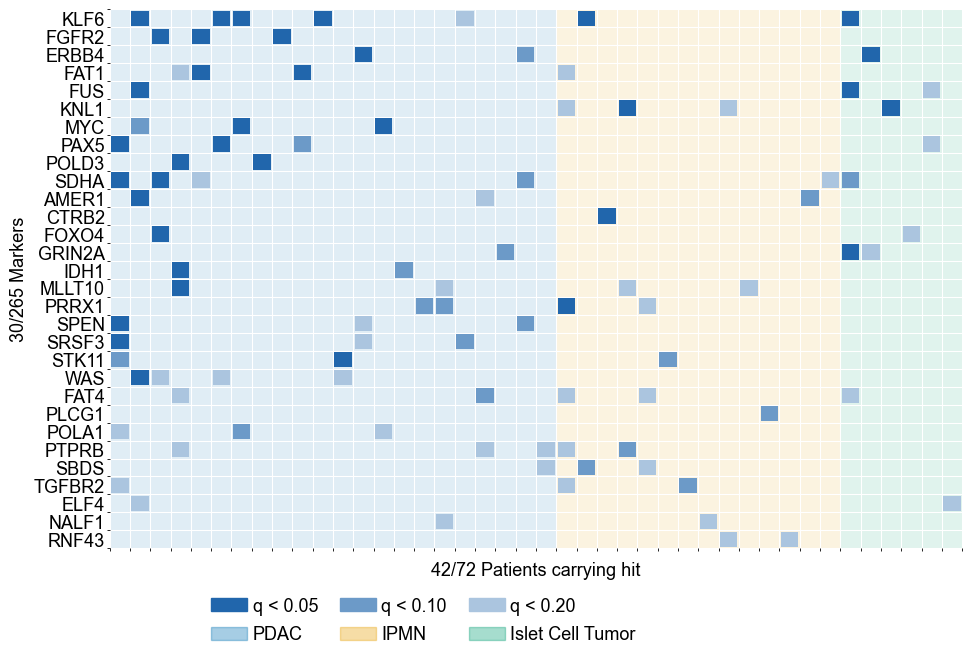

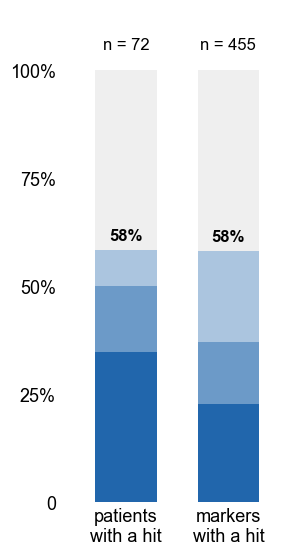

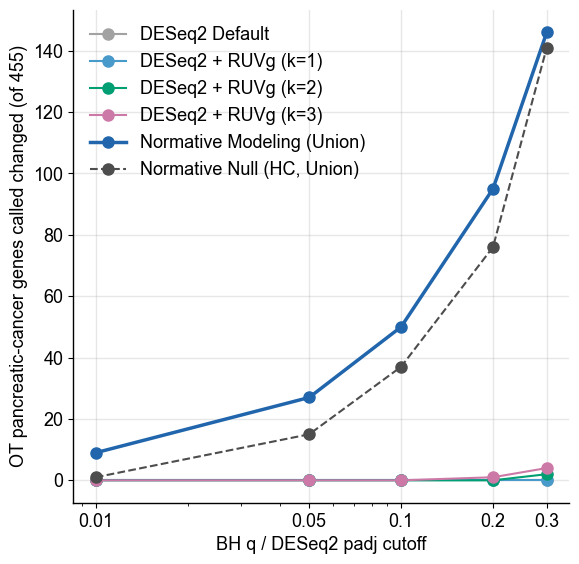

In [70]:
# Same figure on the other kind of panel: Open Targets association genes for pancreatic cancer
# (notebook 4's disease-marker recipe), which are risk/association genes rather than cell-type
# markers. 500 genes is noise-prone at RQR, so this one is restricted to the detected panel.
OT_REF = config.DISEASE_REF_DIR / 'Pancreatic Cancer.json'
OT_TOPN = 500
OT_SCORE_FLOOR = 0.01

ot = json.load(open(OT_REF))
ot_scores = dict(ot['genes'])
ot_syms = set([g for g, s in sorted(ot['genes'], key=lambda gs: -gs[1])
               if s >= OT_SCORE_FLOOR][:OT_TOPN])
sym_g = np.array([sym_of.get(g, g.split('.')[0]) for g in genes])
ot_idx = np.where(np.isin(sym_g, list(ot_syms)))[0]
ot_tbl = pd.DataFrame(dict(ens=genes[ot_idx], symbol=sym_g[ot_idx],
                           score=[ot_scores.get(s, 0.0) for s in sym_g[ot_idx]]))
ot_cnt, _ = raw_counts(np.concatenate([names_neo, names_hc]), ot_tbl['ens'].tolist())
ot_tbl['detect_frac'] = (ot_cnt > 0).mean(axis=0)
ot_tbl['detected'] = ot_tbl['detect_frac'] >= MARKER_MIN_DETECT
ot_tbl.to_csv(OUT / 'ot_marker_panel.csv', index=False)
print(f"OT '{ot['ot_disease']}' ({ot['efo']}): {len(ot_syms)} symbols -> {len(ot_tbl)} genes, "
      f"{int(ot_tbl['detected'].sum())} at detect_frac >= {MARKER_MIN_DETECT}")

ot_recovery = marker_recovery_fig(
    ot_tbl, 'fig_marker_recovery_opentargets.png', 'OT pancreatic-cancer genes called changed',
    color='#2166AC', detected_only=True, nz=ot_cnt[:len(names_neo)] > 0)
ot_recovery.to_csv(OUT / 'ot_marker_recovery_by_cutoff.csv', index=False)


fig_ot_marker_grid_tiers.png: 265 markers x 42 patients; markers by cutoff {0.05: 104, 0.1: 169, 0.2: 265}


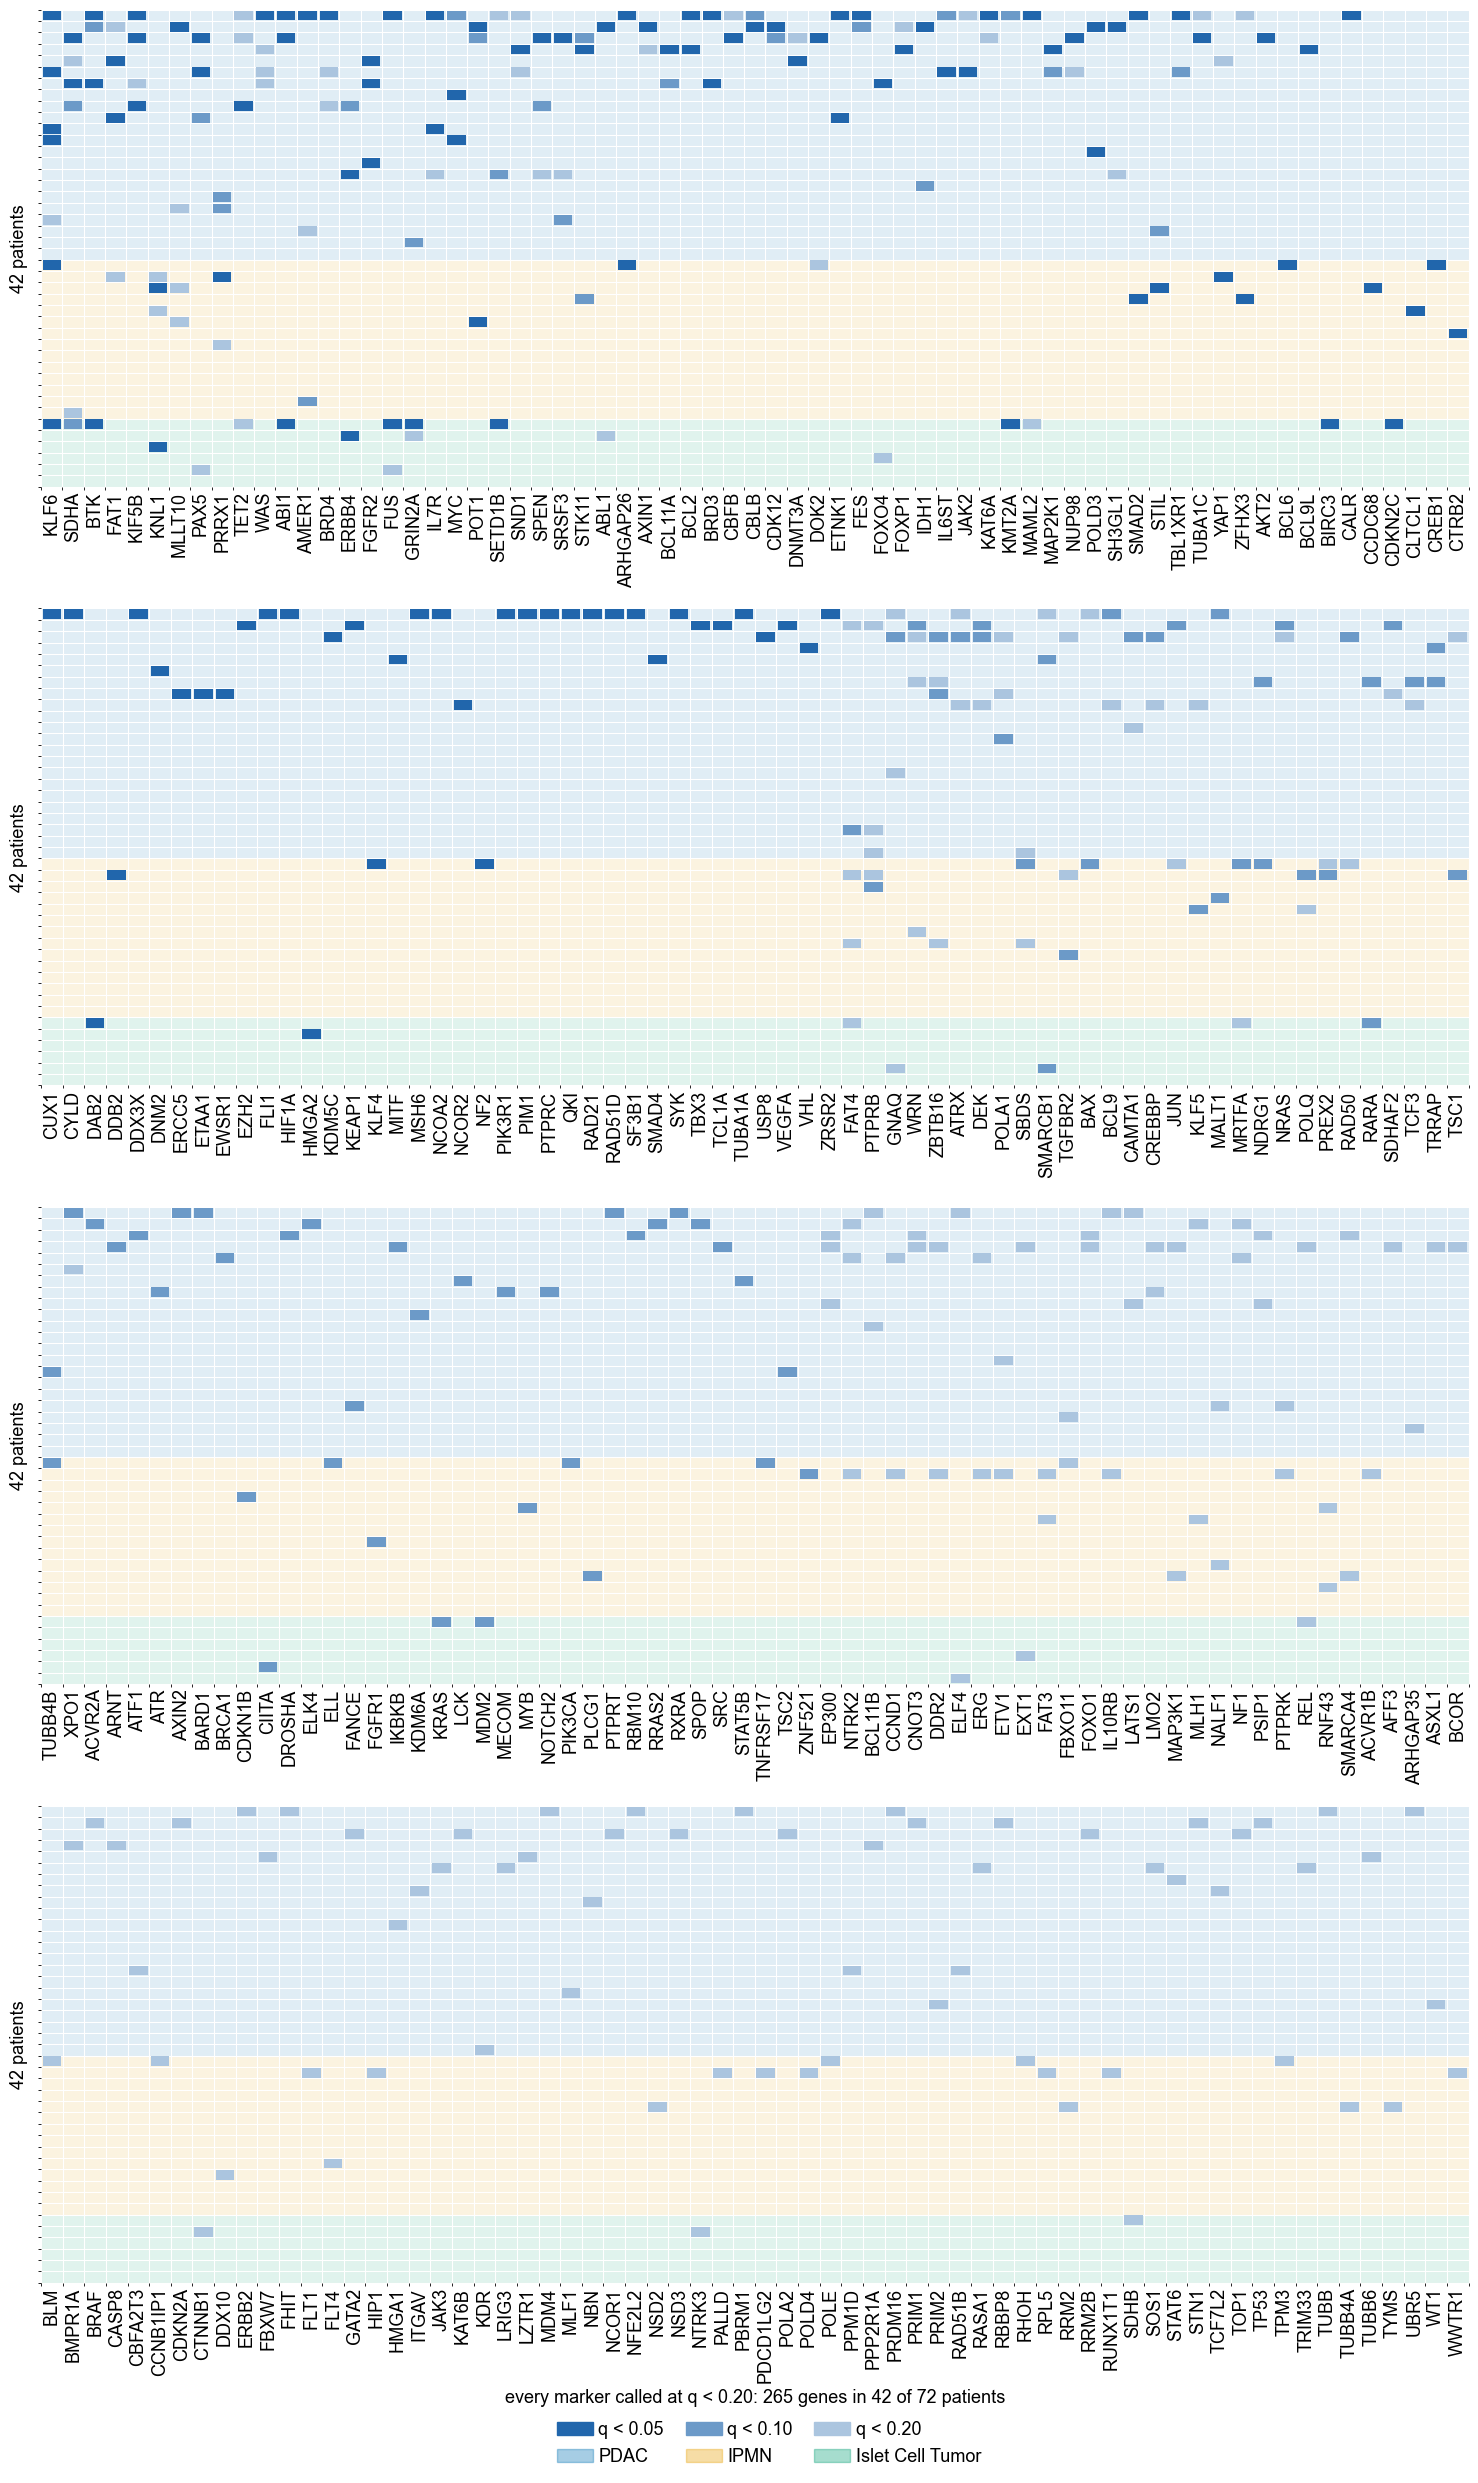

In [71]:
# The whole q-tier set in one place, rotated: markers on x, patients on y. The panel is large
# enough that the 30-row summary above hides most of it, so this one has no row cap and splits
# the markers into GRID_BLOCKS stacked strips. No DESeq2 result is on the other side here, so
# this one runs on the all arm (Moore Batch_1-3) rather than the DESeq2-matched 39.
GRID_BLOCKS = 4
CELL_W, CELL_H = 0.26, 0.14  # inches per marker column / patient row
LABEL_IN = 1.5               # inches reserved under each strip for the rotated gene names


def marker_grid_full(mtbl, fname, color='#B2182B', blocks=GRID_BLOCKS, detected_only=True,
                     labels=None, Z=None, stage=None):
    Z = Z_A if Z is None else Z
    stage = stage_A if stage is None else stage
    lab_of = {**LABELS, **(labels or {})}
    cols = np.array([gpos[e] for e in mtbl['ens']])
    use = mtbl['detected'].values if detected_only else np.ones(len(mtbl), bool)
    sig_q = {q: bh_sig_matrix(Z, q=q)[:, cols] & use[None, :] for q in Q_TIERS}
    tier = np.zeros(sig_q[Q_TIERS[0]].shape)
    for i, q in enumerate(sorted(Q_TIERS, reverse=True)):
        tier[sig_q[q]] = i + 1

    mk = np.where(tier.max(axis=0) > 0)[0]
    mk = mk[np.lexsort((mtbl['symbol'].values[mk], -(tier[:, mk] > 0).sum(axis=0),
                        -tier[:, mk].max(axis=0)))]
    pt = np.where(tier[:, mk].max(axis=1) > 0)[0]
    pt = pt[np.lexsort((-(tier[np.ix_(pt, mk)] == len(Q_TIERS)).sum(axis=1),
                        [list(STAGE_C).index(s) for s in stage[pt]]))]
    chunks = np.array_split(mk, blocks)
    shades = [mcolors.to_hex(1 - w + w * np.array(mcolors.to_rgb(color))) for w in (1.0, 0.66, 0.38)]

    grid_in = CELL_H * len(pt)
    fig, axes = plt.subplots(blocks, 1, figsize=(CELL_W * max(map(len, chunks)) + 1.0,
                                                 blocks * (grid_in + LABEL_IN)),
                             gridspec_kw=dict(hspace=LABEL_IN / grid_in))
    for ax, ch in zip(np.atleast_1d(axes), chunks):
        T = tier[np.ix_(pt, ch)]
        ax.imshow(np.zeros(T.shape), cmap='Greys', vmin=0, vmax=1, aspect='auto')
        for lvl, sh in zip(range(len(Q_TIERS), 0, -1), shades):
            for y, x in zip(*np.where(T == lvl)):
                ax.add_patch(plt.Rectangle((x - 0.43, y - 0.43), 0.86, 0.86, color=sh, lw=0,
                                           zorder=2))
        for i, sm in enumerate(stage[pt]):
            ax.add_patch(plt.Rectangle((-0.5, i - 0.5), len(ch), 1, color=STAGE_C[sm],
                                       alpha=0.12, lw=0, zorder=0))
        ax.set_xlim(-0.5, len(ch) - 0.5)
        ax.set_ylim(len(pt) - 0.5, -0.5)
        ax.set_xticks(np.arange(-0.5, len(ch), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(pt), 1), minor=True)
        ax.grid(which='minor', color='#FFFFFF', lw=0.8)
        ax.set_xticks(range(len(ch)), mtbl['symbol'].values[ch], rotation=90)
        ax.set_yticks([])
        ax.set_ylabel(lab_of['grid_full_y'].format(n_pat_hit=len(pt)))
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
    # legend fills column-major, so interleave to put the q tiers on the top row and the
    # subtypes under them
    h1 = [plt.Rectangle((0, 0), 1, 1, color=sh) for sh in shades]
    h2 = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.35) for c in STAGE_C.values()]
    h = [x for pair in zip(h1, h2) for x in pair]
    l = [x for pair in zip([f'q < {q:.2f}' for q in sorted(Q_TIERS)], STAGE_C)
         for x in pair]
    np.atleast_1d(axes)[-1].legend(h, l, frameon=False, loc='upper left',
                                   bbox_to_anchor=(0.35, -LABEL_IN / grid_in), ncol=3,
                                   handletextpad=0.3, columnspacing=1.2)
    np.atleast_1d(axes)[-1].set_xlabel(lab_of['grid_full_x'].format(
        n_markers=len(mk), n_pat_hit=len(pt), n_pat=len(stage)))
    fig.savefig(FIG / fname, dpi=300, bbox_inches='tight')
    counts = {q: int(sig_q[q].any(axis=0).sum()) for q in sorted(Q_TIERS)}
    print(f'{fname}: {len(mk)} markers x {len(pt)} patients; markers by cutoff {counts}')
    return mtbl.iloc[mk].assign(**{f'n_pat_q{q:g}': sig_q[q][:, mk].sum(axis=0) for q in Q_TIERS})

LABELS['grid_full_x'] = ('every marker called at q < 0.20: {n_markers} genes '
                         'in {n_pat_hit} of {n_pat} patients')
LABELS['grid_full_y'] = '{n_pat_hit} patients'
ot_grid = marker_grid_full(ot_tbl, 'fig_ot_marker_grid_tiers.png', color='#2166AC')
ot_grid.to_csv(OUT / 'ot_marker_grid_tiers.csv', index=False)


In [72]:
# Case table. Every panel gene with at least one read is kept -- no detection cutoff, since the
# individual side already pays a BH q<0.05 price. Group side = DESeq2 padj<0.05 in any of the 20 runs.
def case_table(tbl, extra):
    t = tbl.copy()
    c = np.array([gpos[e] for e in t['ens']])
    t['n_pat_bh'] = SIG[:, c].sum(axis=0)
    t['n_hc_bh'] = SIG_HC[:, c].sum(axis=0)
    t['n_pat_z196'] = (np.abs(Z_neo[:, c]) > MARKER_Z).sum(axis=0)
    t['group_padj'] = t['ens'].map(best_padj)
    t['group_lfc'] = t['ens'].map(best_lfc)
    t['indiv'] = t['n_pat_bh'] > 0
    t['group'] = t['group_padj'].fillna(1.0) < DESEQ2_PADJ
    t['measured'] = t['detect_frac'] > 0
    cols = ['symbol', *extra, 'detect_frac', 'n_pat_bh', 'n_hc_bh', 'n_pat_z196', 'group_padj',
            'group_lfc', 'measured']
    return t.sort_values(['n_pat_bh', 'group_padj'], ascending=[False, True]), cols


def sect(t, m, cols, title, n=None):
    print(f'\n--- {title} (n={int(m.sum())}) ---')
    print(t[m][cols].head(n or int(m.sum())).round(4).to_string(index=False) if m.any() else '(none)')


PANELS = {'pancreas cell-type': (marker_tbl, ['set']),
          'pancreatic-cancer (Open Targets)': (ot_tbl, ['score'])}
case_tables = {}
for name, (tbl, extra) in PANELS.items():
    t, cols = case_table(tbl, extra)
    key = 'cell' if 'cell-type' in name else 'cancer'
    case_tables[key] = t
    t.to_csv(OUT / f'case_table_{key}.csv', index=False)
    ok = t['measured']
    print(f"\n===== {name} panel: {len(t)} genes, {int(ok.sum())} with >=1 read, "
          f"{int((~ok).sum())} with none =====")
    sect(t, ok & t['indiv'] & t['group'], cols, 'both sides')
    sect(t, ok & t['indiv'] & ~t['group'], cols, 'individual only', 25)
    sect(t, ok & ~t['indiv'] & t['group'], cols, 'group only', 15)
    sect(t, ok & ~t['indiv'] & ~t['group'], cols, 'neither -- measured but silent on both sides', 10)
    sect(t, ~ok & (t['n_pat_z196'] > 0), cols, 'zero reads everywhere, yet |Z|>1.96 -- RQR noise floor')
    sect(t, ok & (t['n_hc_bh'] > 0), cols, 'also BH-significant in >=1 HC -- read with caution')


===== pancreas cell-type panel: 106 genes, 93 with >=1 read, 13 with none =====

--- both sides (n=2) ---
 symbol    set  detect_frac  n_pat_bh  n_hc_bh  n_pat_z196  group_padj  group_lfc  measured
   SAA1 ductal       0.1149         1        0           6         0.0     3.3395      True
RIPPLY2  islet       0.0460         1        0           3         0.0     3.4429      True

--- individual only (n=9) ---
  symbol    set  detect_frac  n_pat_bh  n_hc_bh  n_pat_z196  group_padj  group_lfc  measured
   UNC5C  islet       0.3563         2        0           9      0.5618     2.4564      True
    CPB1 acinar       0.0805         1        0           5      0.5655     1.5864      True
   FXYD5  islet       1.0000         1        0          13      0.5998    -0.1229      True
    MAFA  islet       0.2184         1        0           2      0.8047     2.1431      True
   LOXL4  islet       0.0575         1        0           4      0.8403     2.5612      True
PNLIPRP1 acinar       0.0575

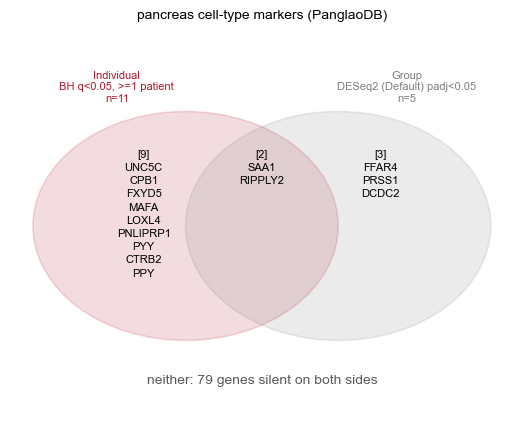

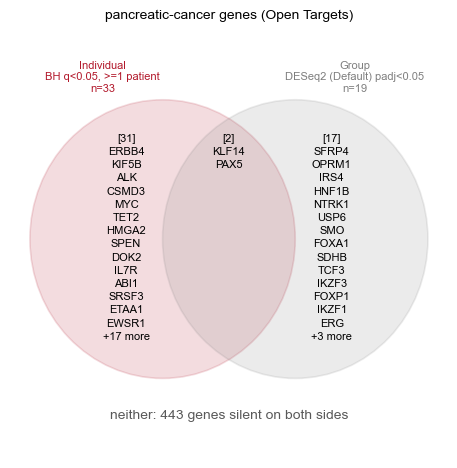

In [73]:
from matplotlib.patches import Ellipse

VENN_TOP = 14
LINE_H = 0.20          # data units per text line at FS_ANNOT_SM, linespacing included
C_IND, C_GRP = '#B2182B', '#7F7F7F'


def venn_case(ax, t, title):
    ok = t['measured']
    both = t[ok & t['indiv'] & t['group']]
    io = t[ok & t['indiv'] & ~t['group']]
    go = t[ok & ~t['indiv'] & t['group']].sort_values('group_padj')

    def block(df):
        s = df['symbol'].head(VENN_TOP).tolist()
        rest = len(df) - len(s)
        body = s if s else ['(none)']
        if rest > 0:
            body = body + [f'+{rest} more']
        return f'[{len(df)}]\n' + '\n'.join(body), len(body) + 1

    blocks = [block(d) for d in (io, both, go)]
    h = max(n for _, n in blocks) * LINE_H
    for x, c, lab, n in ((-1, C_IND, 'Individual\nBH q<0.05, >=1 patient', len(both) + len(io)),
                         (1, C_GRP, 'Group\nDESeq2 (Default) padj<0.05', len(both) + len(go))):
        ax.add_patch(Ellipse((x, 0), 4.0, h + 1.0, facecolor=c, alpha=0.15, edgecolor=c, lw=1.2))
        ax.text(x * 1.9, h / 2 + 0.6, f'{lab}\nn={n}', ha='center', va='bottom', color=c)
    for x, (txt, _) in zip((-1.55, 0.0, 1.55), blocks):
        ax.text(x, h / 2, txt, ha='center', va='top', linespacing=1.4)

    silent = int((ok & ~t['indiv'] & ~t['group']).sum())
    ax.text(0, -h / 2 - 0.95, f'neither: {silent} genes silent on both sides',
            ha='center', va='top', color='0.35', fontsize=10)
    ax.set_title(title, fontsize=FS_ANNOT_SM + 2)
    ax.set_xlim(-3.3, 3.3)
    ax.set_ylim(-h / 2 - 1.7, h / 2 + 1.6)
    ax.set_aspect('equal')
    ax.axis('off')


with plt.rc_context({k: FS_ANNOT_SM for k in ("font.size", "axes.titlesize")}):
    # 1. Cell-type markers
    fig1, ax1 = plt.subplots(figsize=(6.5, 5.6))
    venn_case(ax1, case_tables["cell"], "pancreas cell-type markers (PanglaoDB)")
    fig1.savefig(FIG / "fig_case_venn_cell.png", dpi=300, bbox_inches="tight")
    # 2. Cancer genes
    fig2, ax2 = plt.subplots(figsize=(6.5, 5.6))
    venn_case(
        ax2, case_tables["cancer"], "pancreatic-cancer genes (Open Targets)"
    )
    fig2.savefig(FIG / "fig_case_venn_cancer.png", dpi=300, bbox_inches="tight")


## Act 4 -- the genes only the group contrast calls

`deg_orphan` from act 1, opened up. Every gene the matched run calls at `padj<0.05` is split by
whether DESeq2's LFC saturated (`|LFC| > SAT_LFC`, the separation bound: one arm all zero).

The saturated orphans fall into two cases, and the figure gives each its own panel. **Case 1**: the
one sample carrying the gene's reads is a healthy control, so the contrast is a control-side
outlier and there is no deviant patient for the per-sample view to find. **Case 2**: the peak is a
patient, but the gene is sporadically expressed across the full HC pool the model was fit on, so
the healthy predictive distribution already covers that value and `|Z|` stays under what per-sample
BH demands over `len(genes)` tests.

The graded orphans are a separate axis: there the patient group's mean Z is compared against the
mean Z of every healthy batch, to ask whether the shift is exceptional at all.

In [74]:
from scipy.stats import mannwhitneyu

ORPH_DESIGN, ORPH_CASE, ORPH_GRP = RUVG_PICK, 'PancreaticNeoplasm', 'all neoplasm'
SAT_LFC = 20
ORPH_PATH = OUT / 'orphan_diag.csv'

m_orph = group_mask(ORPH_GRP)
D_orph = sorted(deg[(ORPH_CASE, ORPH_DESIGN)])
nm_orph = set(genes[SIG[m_orph].any(axis=0)])
orph_cols = np.array([gpos[g] for g in D_orph])
orph_samples = np.concatenate([names_neo[m_orph], names_hc])
orph_is_pat = np.arange(len(orph_samples)) < int(m_orph.sum())

if ORPH_PATH.exists():
    orph = pd.read_csv(ORPH_PATH)
else:
    Zp, Zh = Z_neo[np.ix_(m_orph, orph_cols)], Z_hc_qc[:, orph_cols]
    r_orph = pd.read_csv(DEG_DIR / f'moore_b1__{ORPH_CASE}' /
                         f'{ORPH_DESIGN}.csv.gz', index_col=0).reindex(D_orph)
    cnt_o, lib_o = raw_counts(orph_samples, D_orph)
    tot_o = cnt_o.sum(axis=0)
    orph = pd.DataFrame(dict(
        ens=D_orph, symbol=[sym_of.get(g, g.split('.')[0]) for g in D_orph],
        orphan=[g not in nm_orph for g in D_orph],
        baseMean=r_orph['baseMean'].values, lfc=r_orph['log2FoldChange'].values,
        padj=r_orph['padj'].values,
        detect_pat=(cnt_o[orph_is_pat] > 0).mean(axis=0),
        detect_hc=(cnt_o[~orph_is_pat] > 0).mean(axis=0),
        n_nonzero=(cnt_o > 0).sum(axis=0), tot_counts=tot_o,
        top1_share=cnt_o.max(axis=0) / np.maximum(tot_o, 1),
        driver_is_hc=[not orph_is_pat[cnt_o[:, k].argmax()] for k in range(cnt_o.shape[1])],
        meanZ_pat=Zp.mean(axis=0), sdZ_pat=Zp.std(axis=0, ddof=1), meanZ_hc=Zh.mean(axis=0),
        maxabsZ_pat=np.abs(Zp).max(axis=0),
        n_z196=(np.abs(Zp) > MARKER_Z).sum(axis=0),
        n_bh=SIG[np.ix_(m_orph, orph_cols)].sum(axis=0),
        mwu_p=[mannwhitneyu(Zp[:, k], Zh[:, k]).pvalue for k in range(Zp.shape[1])]))
    orph['klass'] = np.where(orph['lfc'].abs() > SAT_LFC, 'saturated', 'graded')
    orph.to_csv(ORPH_PATH, index=False)

HC_POOL_PATH = OUT / 'orphan_hc_pool_cpm.npy'

hc_pool = pd.read_csv(config.ZSCORES_MIXED_DIR / 'hc_meta.csv')['sample'].values
if HC_POOL_PATH.exists():
    hc_pool_cpm = np.load(HC_POOL_PATH)
else:
    cnt_p, lib_p = raw_counts(hc_pool, D_orph)
    hc_pool_cpm = cnt_p / lib_p[:, None] * 1e6
    np.save(HC_POOL_PATH, hc_pool_cpm)

orph = orph.set_index('ens').reindex(D_orph).reset_index()
orph['hc_pool_nz'] = (hc_pool_cpm > 0).sum(axis=0)
orph['hc_pool_maxcpm'] = hc_pool_cpm.max(axis=0)
orph['case'] = np.where(~orph['orphan'], 'also NM',
                        np.where(orph['driver_is_hc'], 'HC outlier', 'below threshold'))

print(f'{ORPH_DESIGN} / {ORPH_CASE}: {len(orph)} DE genes, '
      f'{int(orph.orphan.sum())} called by no single patient  '
      f'(patients n={int(m_orph.sum())}, batch-matched HC n={len(names_hc)})')
print(orph.groupby(['klass', 'orphan'])
      .agg(n=('ens', 'size'), top1_share=('top1_share', 'median'),
           n_nonzero=('n_nonzero', 'median'), tot_counts=('tot_counts', 'median'),
           driver_is_hc=('driver_is_hc', 'mean'), maxabsZ_pat=('maxabsZ_pat', 'median'),
           abs_meanZ_pat=('meanZ_pat', lambda s: s.abs().median()),
           n_bh=('n_bh', 'median')).round(3).to_string())
print(f'healthy pool behind the Z: {len(hc_pool)} HC samples')
print(orph[orph['klass'] == 'saturated'].groupby('case')
      .agg(n=('ens', 'size'), top1_share=('top1_share', 'median'),
           n_nonzero=('n_nonzero', 'median'), hc_pool_nz=('hc_pool_nz', 'median'),
           maxabsZ_pat=('maxabsZ_pat', 'median'), n_bh=('n_bh', 'median')).round(2).to_string())

ruvg_k2 / PancreaticNeoplasm: 77 DE genes, 56 called by no single patient  (patients n=39, batch-matched HC n=48)
                   n  top1_share  n_nonzero  tot_counts  driver_is_hc  maxabsZ_pat  abs_meanZ_pat  n_bh
klass     orphan                                                                                       
graded    False    2       0.483       72.0  111198.997         0.000        5.189          0.792   2.5
          True    13       0.454       23.0    1365.000         0.385        2.879          0.228   0.0
saturated False   19       0.892        3.0     212.000         0.000        5.034          0.174   1.0
          True    43       0.906        4.0     172.101         0.674        2.294          0.131   0.0
healthy pool behind the Z: 679 HC samples
                  n  top1_share  n_nonzero  hc_pool_nz  maxabsZ_pat  n_bh
case                                                                     
HC outlier       29        0.93        3.0       100.0         2.08   0.

           case          symbol     lfc  padj  n_nonzero  top1_share  hc_pool_nz  hc_pool_maxcpm  maxabsZ_pat  n_bh
     HC outlier         ANGPTL8 -43.281 0.000          2       0.969          28          13.784        2.190     0
     HC outlier           PRR35 -43.281 0.000          9       0.955         201          16.539        2.499     0
     HC outlier ENSG00000261793 -43.281 0.000          1       1.000          34          11.762        1.733     0
     HC outlier          SMIM17 -43.281 0.000          1       1.000          56           3.436        1.972     0
     HC outlier           MCHR2 -43.281 0.000          1       1.000          34          16.984        2.120     0
     HC outlier            PXT1 -43.281 0.000          2       0.928          42           9.026        1.939     0
     HC outlier             SP7 -43.281 0.000          4       0.906         132           7.408        2.203     0
     HC outlier           ASIC1 -43.281 0.000          4       0.935    

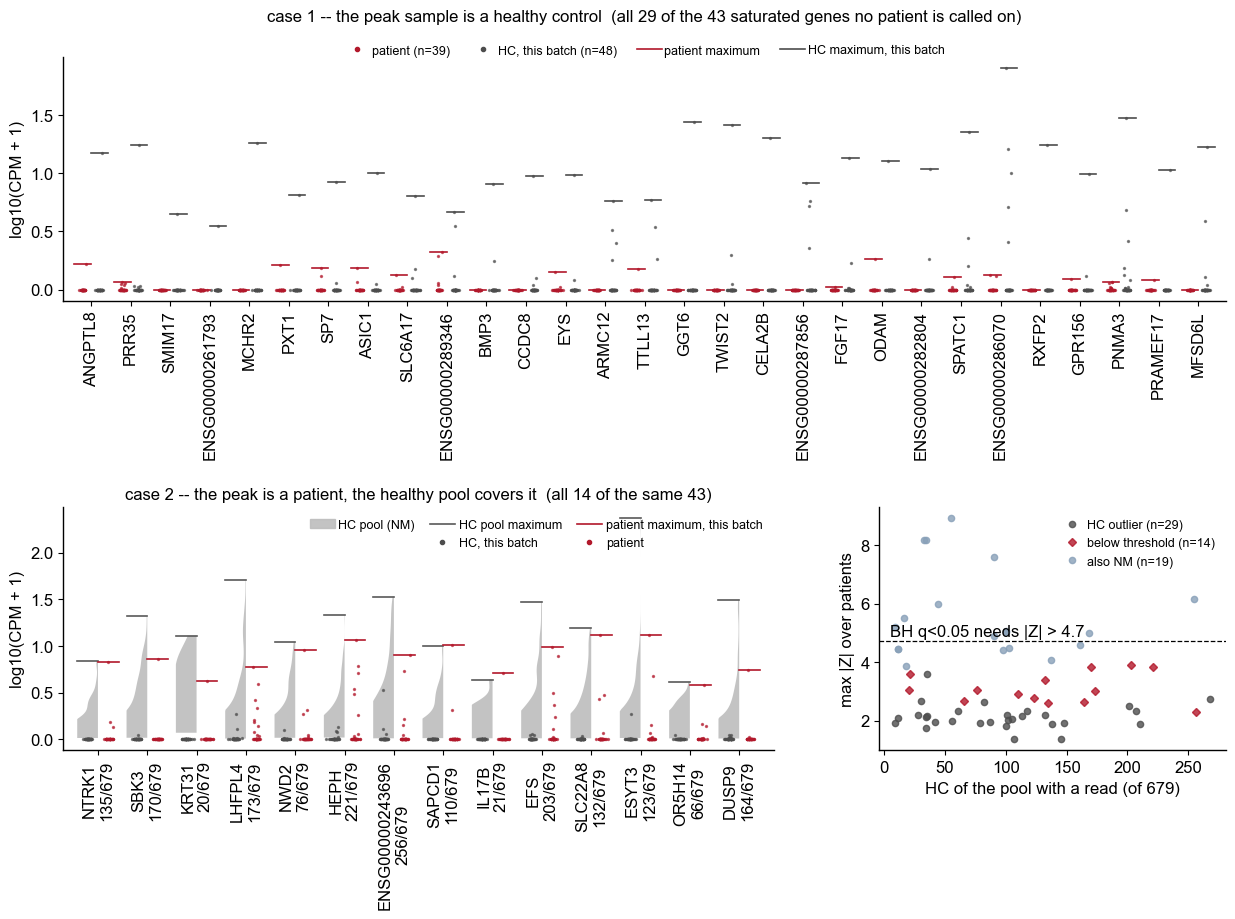

In [75]:
FS_LG = dict.fromkeys(FS, FS_ANNOT_LG)
C_PATIENT, C_HEALTHY, C_POOL = '#B2182B', '#4D4D4D', '#BDBDBD'
BH_Z = float(norm.isf(FDR_Q / len(genes) / 2))

sat_pos = np.where(orph['klass'].values == 'saturated')[0]
sat = orph.iloc[sat_pos]
cnt_s, lib_s = raw_counts(orph_samples, sat['ens'].tolist())
cpm_s = np.log10(cnt_s / lib_s[:, None] * 1e6 + 1)
pool_s = np.log10(hc_pool_cpm[:, sat_pos] + 1)


def pick(case):
    c = np.where(sat['case'].values == case)[0]
    return c[np.argsort(sat['padj'].values[c])]


def jitter(ax, k, off, v, col, rj):
    ax.plot(k + off + rj.normal(0, 0.045, len(v)), v, '.', ms=2.8, color=col, alpha=0.65)


def gene_axis(ax, cols, extra=None):
    ax.set_xticks(range(len(cols)))
    lab = sat['symbol'].values[cols]
    ax.set_xticklabels(lab if extra is None else [f'{s}\n{e}' for s, e in zip(lab, extra)],
                       rotation=90)
    ax.set_ylabel('log10(CPM + 1)')
    ax.set_xlim(-0.7, len(cols) - 0.3)


c1, c2 = pick('HC outlier'), pick('below threshold')
n_sat_orph = int(sat['orphan'].sum())

with plt.rc_context(FS_LG):
    fig = plt.figure(figsize=(15.0, 9.0))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.05, 1.0], hspace=0.85, wspace=0.2)

    ax = fig.add_subplot(gs[0, :])
    rj = np.random.default_rng(SEED)
    for k, c in enumerate(c1):
        jitter(ax, k, -0.2, cpm_s[orph_is_pat, c], C_PATIENT, rj)
        jitter(ax, k, 0.2, cpm_s[~orph_is_pat, c], C_HEALTHY, rj)
        ax.plot([k - 0.42, k], [cpm_s[orph_is_pat, c].max()] * 2, color=C_PATIENT, lw=1.2,
                zorder=6)
        ax.plot([k, k + 0.42], [cpm_s[~orph_is_pat, c].max()] * 2, color=C_HEALTHY, lw=1.2,
                zorder=6)
    gene_axis(ax, c1)
    ax.set_title('case 1 -- the peak sample is a healthy control  '
                 f'(all {len(c1)} of the {n_sat_orph} saturated genes no patient is called on)',
                 fontsize=FS_ANNOT_LG, pad=26)
    ax.plot([], [], 'o', ms=3, color=C_PATIENT, label=f'patient (n={int(orph_is_pat.sum())})')
    ax.plot([], [], 'o', ms=3, color=C_HEALTHY,
            label=f'HC, this batch (n={int((~orph_is_pat).sum())})')
    ax.plot([], [], '-', color=C_PATIENT, lw=1.2, label='patient maximum')
    ax.plot([], [], '-', color=C_HEALTHY, lw=1.2, label='HC maximum, this batch')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=4, frameon=False,
              handletextpad=0.2, columnspacing=1.6, fontsize=9)

    ax = fig.add_subplot(gs[1, 0])
    rj = np.random.default_rng(SEED)
    pool_nz_lab = []
    for k, c in enumerate(c2):
        nzv = pool_s[pool_s[:, c] > 0, c]
        pool_nz_lab.append(f'{len(nzv)}/{len(hc_pool)}')
        v = ax.violinplot(nzv, positions=[k], widths=1.5, showextrema=False)
        body = v['bodies'][0]
        body.set(facecolor=C_POOL, alpha=0.9, edgecolor='none', zorder=0)
        vt = body.get_paths()[0].vertices
        vt[:, 0] = np.clip(vt[:, 0], k - 0.42, k)
        ax.plot([k - 0.42, k], [nzv.max()] * 2, color='0.35', lw=1.2, zorder=6)
        ax.plot([k, k + 0.42], [cpm_s[orph_is_pat, c].max()] * 2, color=C_PATIENT, lw=1.2,
                zorder=6)
        jitter(ax, k, -0.2, cpm_s[~orph_is_pat, c], C_HEALTHY, rj)
        jitter(ax, k, 0.22, cpm_s[orph_is_pat, c], C_PATIENT, rj)
    gene_axis(ax, c2, pool_nz_lab)
    ax.set_title('case 2 -- the peak is a patient, the healthy pool covers it  '
                 f'(all {len(c2)} of the same {n_sat_orph})', fontsize=FS_ANNOT_LG)
    ax.fill_between([], [], color=C_POOL, alpha=0.9, label='HC pool (NM)')
    ax.plot([], [], ls='', marker='', label=' ')
    ax.plot([], [], '-', color='0.35', lw=1.2, label='HC pool maximum')
    ax.plot([], [], 'o', ms=3, color=C_HEALTHY, label='HC, this batch')
    ax.plot([], [], '-', color=C_PATIENT, lw=1.2, label='patient maximum, this batch')
    ax.plot([], [], 'o', ms=3, color=C_PATIENT, label='patient')
    ax.legend(loc='upper right', ncol=3, frameon=False, handletextpad=0.3, columnspacing=1.2 , fontsize=9)

    ax = fig.add_subplot(gs[1, 1])
    for case, col, mk in (('HC outlier', C_HEALTHY, 'o'), ('below threshold', C_PATIENT, 'D'),
                          ('also NM', '#88A0B8', 'o')):
        sel = sat['case'].values == case
        ax.plot(sat['hc_pool_nz'].values[sel], sat['maxabsZ_pat'].values[sel], mk, ms=4.5,
                color=col, alpha=0.8, label=f'{case} (n={int(sel.sum())})')
    ax.axhline(BH_Z, color='k', lw=0.9, ls='--')
    ax.annotate(f'BH q<{FDR_Q} needs |Z| > {BH_Z:.1f}', (0.03, BH_Z),
                xycoords=('axes fraction', 'data'), textcoords='offset points', xytext=(0, 4),
                fontsize=FS_ANNOT_LG)
    ax.set_xlabel(f'HC of the pool with a read (of {len(hc_pool)})')
    ax.set_ylabel('max |Z| over patients')
    ax.legend(loc='upper right', frameon=False, handletextpad=0.2, fontsize=9)

fig.savefig(FIG / 'fig_orphan_saturated.png', dpi=300, bbox_inches='tight')
print(sat[sat['case'] != 'also NM'].sort_values(['case', 'padj'])[
    ['case', 'symbol', 'lfc', 'padj', 'n_nonzero', 'top1_share', 'hc_pool_nz', 'hc_pool_maxcpm',
     'maxabsZ_pat', 'n_bh']].round(3).to_string(index=False))

In [76]:
HC_BATCH_MIN = 20
GRADED_PATH = OUT / 'graded_orphan_batchhc.csv'

if GRADED_PATH.exists():
    graded = pd.read_csv(GRADED_PATH)
else:
    graded = orph[(orph['klass'] == 'graded') & orph['orphan']].copy()
    gcols = np.array([gpos[e] for e in graded['ens']])
    hc_meta_all = pd.read_csv(config.ZSCORES_MIXED_DIR / 'hc_meta.csv')
    Z_hc_all = np.load(config.ZSCORES_MIXED_DIR / 'Z_hc_shash.npy')[:, gcols]
    sizes = hc_meta_all.groupby('batch').size()
    hc_batches = sizes[sizes >= HC_BATCH_MIN].index.tolist()
    B = np.vstack([Z_hc_all[(hc_meta_all['batch'] == b).values].mean(axis=0) for b in hc_batches])
    other = B[[i for i, b in enumerate(hc_batches) if b != MATCHED_BATCH]]
    graded['hc_batch_lo'] = B.min(axis=0)
    graded['hc_batch_hi'] = B.max(axis=0)
    graded['hc_batch_sd'] = B.std(axis=0, ddof=1)
    graded['hc_other_absmax'] = np.abs(other).max(axis=0)
    graded['pat_rank_vs_hc'] = (np.abs(other) >= np.abs(graded['meanZ_pat'].values)[None, :]).mean(axis=0)
    graded['patient_specific'] = graded['pat_rank_vs_hc'] == 0
    graded = graded.sort_values('meanZ_pat')
    graded.to_csv(GRADED_PATH, index=False)
    print(f'HC batches with n >= {HC_BATCH_MIN}: {len(hc_batches)} '
          f'(sizes {sizes[hc_batches].min()}-{sizes[hc_batches].max()})')

print(f'graded orphans: {len(graded)}')
print(graded[['meanZ_pat', 'meanZ_hc', 'hc_batch_sd', 'hc_other_absmax',
              'pat_rank_vs_hc']].median().round(3).to_string())
print(f"\npatient |mean Z| exceeded by at least one healthy batch: "
      f"{int((graded.hc_other_absmax >= graded.meanZ_pat.abs()).sum())}/{len(graded)}")
print(f"outside every healthy batch mean: "
      f"{int(graded.patient_specific.sum())}/{len(graded)} "
      f"({', '.join(graded.loc[graded.patient_specific, 'symbol'])})")

graded orphans: 13
meanZ_pat          0.171
meanZ_hc          -0.199
hc_batch_sd        0.253
hc_other_absmax    0.501
pat_rank_vs_hc     0.444

patient |mean Z| exceeded by at least one healthy batch: 12/13
outside every healthy batch mean: 1/13 (LIPN)
